# 01 — Pendulum policy checkpoints and action-level DPO diagnostic

**Purpose.** This notebook contains the Pendulum PPO policy checkpoints and the action-level DPO diagnostic experiments.

**What is done here:**
1. train or load PPO policies for Pendulum-v1: a stronger policy $\pi_1$ and a weaker/intermediate policy $\pi_2$;
2. evaluate the selected policies and optionally record rollouts;
3. build action-level preference data of the form $(s, a^+, a^-)$, where $a^+$ comes from $\pi_1$ and $a^-$ comes from $\pi_2$ at the same state;
4. run action-level DPO diagnostics, including beta / learning-rate / dataset-size checks;
5. use these diagnostics only to understand why pure trajectory-level DPO struggles on Pendulum.

**Important note.** Action-level DPO is an ablation/diagnostic, not the main DPO result. It is used for more local supervision than trajectory-level DPO, so it was used to support the credit-assignment explanation, not as a direct replacement for the main trajectory-level DPO comparison.


In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt
import random
import copy
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

Lets do new one

In [3]:
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy as sb3_evaluate_policy

In [54]:
env = gym.make("Pendulum-v1")

ppo_model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1,
    seed=42,
)

# First train a little and save this as weaker checkpoint π2
ppo_model.learn(total_timesteps=20_000)
ppo_model.save("pendulum_ppo_pi2_checkpoint")

# Continue training the SAME model to get stronger π1
ppo_model.learn(total_timesteps=180_000)
ppo_model.save("pendulum_ppo_pi1_expert")

env.close()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.26e+03 |
| time/              |           |
|    fps             | 1095      |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -1.2e+03     |
| time/                   |              |
|    fps                  | 705          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0040680366 |
|    clip_fraction        | 0.0343       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | 0.00859      |
|    

In [55]:
ppo_pi2 = PPO.load("pendulum_ppo_pi2_checkpoint")
ppo_pi1 = PPO.load("pendulum_ppo_pi1_expert")

In [19]:
def evaluate_sb3_policy(model, env_name="Pendulum-v1", episodes=100):
    env = gym.make(env_name)
    rewards = []

    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    env.close()
    return np.mean(rewards), np.std(rewards), rewards

In [56]:
eval_env = gym.make("Pendulum-v1")

ppo_pi1_mean, ppo_pi1_std = sb3_evaluate_policy(
    ppo_pi1,
    eval_env,
    n_eval_episodes=100,
    deterministic=True
)

ppo_pi2_mean, ppo_pi2_std = sb3_evaluate_policy(
    ppo_pi2,
    eval_env,
    n_eval_episodes=100,
    deterministic=True
)

eval_env.close()

print("PPO π1 mean:", ppo_pi1_mean, "std:", ppo_pi1_std)
print("PPO π2 mean:", ppo_pi2_mean, "std:", ppo_pi2_std)

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO π1 mean: -564.6810325341949 std: 210.4864201717684
PPO π2 mean: -1158.5738658295036 std: 327.97324419325736


PPO π1: -594.5699330583783 226.04328665305073
PPO π2: -1146.1726842350931 322.23031063070675


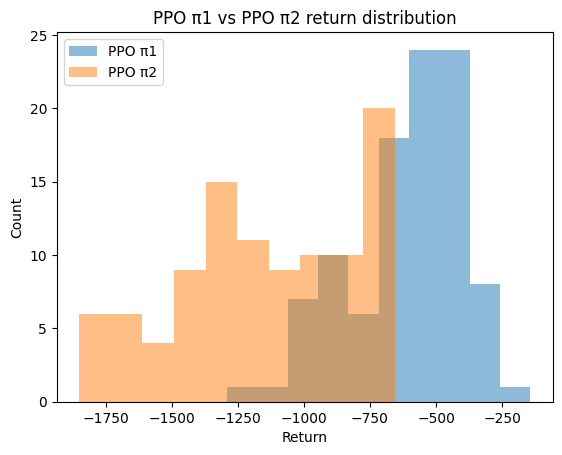

In [58]:
ppo_mean1, ppo_std1, ppo_rewards1 = evaluate_sb3_policy(ppo_pi1, episodes=100)
ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(ppo_pi2, episodes=100)

print("PPO π1:", ppo_mean1, ppo_std1)
print("PPO π2:", ppo_mean2, ppo_std2)

plt.hist(ppo_rewards1, alpha=0.5, label="PPO π1")
plt.hist(ppo_rewards2, alpha=0.5, label="PPO π2")
plt.legend()
plt.title("PPO π1 vs PPO π2 return distribution")
plt.xlabel("Return")
plt.ylabel("Count")
plt.show()

In [20]:
import imageio
from IPython.display import Video, display

def record_sb3_policy(model, env_name="Pendulum-v1", filename="pendulum_sb3.mp4", max_steps=200):
    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset()

    frames = []
    total_reward = 0.0

    for _ in range(max_steps):
        frames.append(env.render())

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)

        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    imageio.mimsave(filename, frames, fps=30)
    print("Saved:", filename)
    print("Total reward:", total_reward)

    return filename

In [60]:
record_sb3_policy(ppo_pi1, filename="pendulum_ppo_pi1.mp4")
record_sb3_policy(ppo_pi2, filename="pendulum_ppo_pi2.mp4")

display(Video("pendulum_ppo_pi1.mp4", embed=True))
display(Video("pendulum_ppo_pi2.mp4", embed=True))

Failed to create secure directory (/run/user/308942/pulse): No such file or directory
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 500) to (512, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: pendulum_ppo_pi1.mp4
Total reward: -534.1042505327877


Failed to create secure directory (/run/user/308942/pulse): No such file or directory
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 500) to (512, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: pendulum_ppo_pi2.mp4
Total reward: -1608.4198705933622


In [61]:
ppo_pi1.save("pendulum_ppo_pi1_good_minus595")
ppo_pi2.save("pendulum_ppo_pi2_half_minus1146")

In [62]:
env = gym.make("Pendulum-v1")

ppo_pi1 = PPO.load("pendulum_ppo_pi1_good_minus595", env=env)

ppo_pi1.learn(
    total_timesteps=100_000,
    reset_num_timesteps=False
)

ppo_pi1.save("pendulum_ppo_pi1_longer")
env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -712     |
| time/              |          |
|    fps             | 1179     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 182272   |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -680        |
| time/                   |             |
|    fps                  | 893         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 184320      |
| train/                  |             |
|    approx_kl            | 0.007240167 |
|    clip_fraction        | 0.0714      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.845   

PPO π1: -179.93481886131073 108.44295826347313
PPO π2: -1163.1584907388299 278.40509927227623


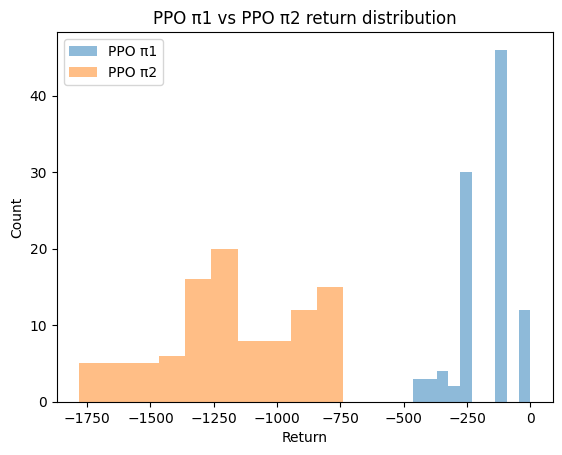

In [63]:
ppo_mean1, ppo_std1, ppo_rewards1 = evaluate_sb3_policy(ppo_pi1, episodes=100)
ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(ppo_pi2, episodes=100)

print("PPO π1:", ppo_mean1, ppo_std1)
print("PPO π2:", ppo_mean2, ppo_std2)

plt.hist(ppo_rewards1, alpha=0.5, label="PPO π1")
plt.hist(ppo_rewards2, alpha=0.5, label="PPO π2")
plt.legend()
plt.title("PPO π1 vs PPO π2 return distribution")
plt.xlabel("Return")
plt.ylabel("Count")
plt.show()

In [64]:
ppo_pi1.save("pendulum_ppo_pi1_expert_minus180")


In [65]:
ppo_pi2 = PPO.load("pendulum_ppo_pi2_half_minus1146", env=env)

ppo_pi2.learn(
    total_timesteps=100_000,      
    reset_num_timesteps=False
)

ppo_pi2.save("pendulum_ppo_pi2_longer_100k")

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.17e+03 |
| time/              |           |
|    fps             | 1163      |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 22528     |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -1.18e+03    |
| time/                   |              |
|    fps                  | 880          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 24576        |
| train/                  |              |
|    approx_kl            | 0.0028117741 |
|    clip_fraction        | 0.0132       |
|    clip_range           | 0.2          |
|    entropy_l

In [66]:
ppo_pi1 = PPO.load("pendulum_ppo_pi1_expert_minus180")
ppo_pi2 = PPO.load("pendulum_ppo_pi2_longer_100k")

ppo_mean1, ppo_std1, ppo_rewards1 = evaluate_sb3_policy(
    ppo_pi1,
    episodes=100
)

ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(
    ppo_pi2,
    episodes=100
)

print("PPO π1 longer:", ppo_mean1, ppo_std1)
print("PPO π2 longer:", ppo_mean2, ppo_std2)

PPO π1 longer: -179.58903158388748 118.56593900535637
PPO π2 longer: -939.2824191420666 171.22049873200567


In [67]:
ppo_pi1.save("pendulum_ppo_pi1_final_expert_minus180")
ppo_pi2.save("pendulum_ppo_pi2_final_half_minus939")

print("Saved final PPO π1 and π2.")

Saved final PPO π1 and π2.


In [55]:
ppo_pi1 = PPO.load("pendulum_ppo_pi1_expert_minus180")
ppo_pi2 = PPO.load("pendulum_ppo_pi2_longer_100k")

In [23]:
def rollout_sb3_policy(model, env, max_steps=200, deterministic=True):
    obs, _ = env.reset()
    traj = []
    total_reward = 0.0

    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=deterministic)

        next_obs, reward, terminated, truncated, _ = env.step(action)

        traj.append((obs.copy(), action.copy(), reward))
        total_reward += reward

        obs = next_obs

        if terminated or truncated:
            break

    return traj, total_reward

In [24]:
from tqdm import tqdm
import numpy as np
import gymnasium as gym

def stable_preference_probability(ret1, ret2):
    # Assignment formula:
    # exp(R1) / (exp(R1) + exp(R2))
    # This is equivalent to sigmoid(R1 - R2), but safer numerically.
    diff = ret1 - ret2

    if diff > 50:
        return 1.0
    elif diff < -50:
        return 0.0
    else:
        return 1.0 / (1.0 + np.exp(-diff))


def generate_sb3_preference_dataset(env_name, pi1_model, pi2_model, K=2000):
    env = gym.make(env_name)
    dataset = []

    for _ in tqdm(range(K), desc="Generating preference pairs"):
        tau1, ret1 = rollout_sb3_policy(pi1_model, env, deterministic=True)
        tau2, ret2 = rollout_sb3_policy(pi2_model, env, deterministic=True)

        p_tau1_preferred = stable_preference_probability(ret1, ret2)

        if np.random.rand() < p_tau1_preferred:
            pref, rej = tau1, tau2
            pref_ret, rej_ret = ret1, ret2
        else:
            pref, rej = tau2, tau1
            pref_ret, rej_ret = ret2, ret1

        dataset.append((pref, rej, pref_ret, rej_ret))

    env.close()
    return dataset

In [32]:
ppo_prefs = generate_sb3_preference_dataset(
    "Pendulum-v1",
    ppo_pi1,
    ppo_pi2,
    K=2000
)

Generating preference pairs: 100%|█████████████████████████████| 2000/2000 [06:45<00:00,  4.93it/s]


In [33]:
pref_returns = []
rej_returns = []
correct = 0

for pref, rej, pref_ret, rej_ret in ppo_prefs:
    pref_returns.append(pref_ret)
    rej_returns.append(rej_ret)

    if pref_ret >= rej_ret:
        correct += 1

print("Preferred trajectory has higher return fraction:", correct / len(ppo_prefs))
print("Mean preferred return:", np.mean(pref_returns))
print("Mean rejected return:", np.mean(rej_returns))

Preferred trajectory has higher return fraction: 1.0
Mean preferred return: -188.71528045173764
Mean rejected return: -917.2649755902889


In [25]:
import random
import torch
import torch.nn.functional as F
from tqdm import tqdm

def sb3_log_prob_traj(model, traj):
    obs = np.array([t[0] for t in traj], dtype=np.float32)
    actions = np.array([t[1] for t in traj], dtype=np.float32)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=model.policy.device)
    actions_t = torch.tensor(actions, dtype=torch.float32, device=model.policy.device)

    dist = model.policy.get_distribution(obs_t)
    log_probs = dist.log_prob(actions_t)

    # Important: average over trajectory, not sum
    return log_probs.mean()

In [26]:
def sb3_dpo_batch_loss(policy_model, ref_model, batch, beta=0.01):
    batch_logits = []

    for pref_traj, rej_traj, _, _ in batch:
        pi_pref = sb3_log_prob_traj(policy_model, pref_traj)
        pi_rej = sb3_log_prob_traj(policy_model, rej_traj)

        with torch.no_grad():
            ref_pref = sb3_log_prob_traj(ref_model, pref_traj)
            ref_rej = sb3_log_prob_traj(ref_model, rej_traj)

        logit = beta * ((pi_pref - pi_rej) - (ref_pref - ref_rej))
        batch_logits.append(logit)

    batch_logits = torch.stack(batch_logits)

    return -F.logsigmoid(batch_logits).mean()

In [27]:
def train_sb3_dpo_stable(
    policy_model,
    ref_model,
    prefs,
    epochs=2,
    batch_size=32,
    lr=1e-6,
    beta=0.01,
):
    policy_model.policy.train()
    ref_model.policy.eval()

    # Freeze reference model completely
    for p in ref_model.policy.parameters():
        p.requires_grad = False

    # Freeze everything first
    for p in policy_model.policy.parameters():
        p.requires_grad = False

    # Train only policy branch + action head
    for p in policy_model.policy.mlp_extractor.policy_net.parameters():
        p.requires_grad = True

    for p in policy_model.policy.action_net.parameters():
        p.requires_grad = True

    # Very important: do not let DPO cheat by changing std
    if hasattr(policy_model.policy, "log_std"):
        policy_model.policy.log_std.requires_grad = False

    trainable_params = [
        p for p in policy_model.policy.parameters()
        if p.requires_grad
    ]

    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    losses = []

    for epoch in range(epochs):
        random.shuffle(prefs)
        total_loss = 0.0
        num_batches = 0

        for start in tqdm(range(0, len(prefs), batch_size), desc=f"Stable DPO epoch {epoch+1}/{epochs}"):
            batch = prefs[start:start + batch_size]

            loss = sb3_dpo_batch_loss(
                policy_model,
                ref_model,
                batch,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, 0.5)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} | DPO loss: {avg_loss:.4f}")

    return policy_model, losses

In [45]:
env = gym.make("Pendulum-v1")

dpo_model = PPO.load("pendulum_ppo_pi2_final_half_minus939", env=env)
ref_model = PPO.load("pendulum_ppo_pi2_final_half_minus939", env=env)

trained_dpo_model, dpo_losses = train_sb3_dpo_stable(
    policy_model=dpo_model,
    ref_model=ref_model,
    prefs=ppo_prefs,
    epochs=2,
    batch_size=32,
    lr=1e-6,
    beta=0.01,
)

trained_dpo_model.save("pendulum_dpo_stable_beta001")

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Stable DPO epoch 1/2: 100%|████████████████████████████████████████| 63/63 [00:07<00:00,  8.67it/s]


Epoch 1/2 | DPO loss: 0.6931


Stable DPO epoch 2/2: 100%|████████████████████████████████████████| 63/63 [00:07<00:00,  8.87it/s]

Epoch 2/2 | DPO loss: 0.6931


In [46]:
# Load final models again to avoid variable-name/kernel confusion
ppo_pi1 = PPO.load("pendulum_ppo_pi1_expert_minus180")
ppo_pi2 = PPO.load("pendulum_ppo_pi2_final_half_minus939")
trained_dpo_model = PPO.load("pendulum_dpo_stable_beta001")

# Evaluate all three with consistent variable names
ppo_mean1, ppo_std1, ppo_rewards1 = evaluate_sb3_policy(
    ppo_pi1,
    episodes=100
)

ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(
    ppo_pi2,
    episodes=100
)

dpo_mean, dpo_std, dpo_rewards = evaluate_sb3_policy(
    trained_dpo_model,
    episodes=100
)

print("PPO π1:", ppo_mean1, ppo_std1)
print("PPO π2:", ppo_mean2, ppo_std2)
print("DPO:", dpo_mean, dpo_std)

PPO π1: -184.53224980412398 119.81637716992601
PPO π2: -886.4204705855301 165.91874525341592
DPO: -898.2147985297202 138.91407294605722


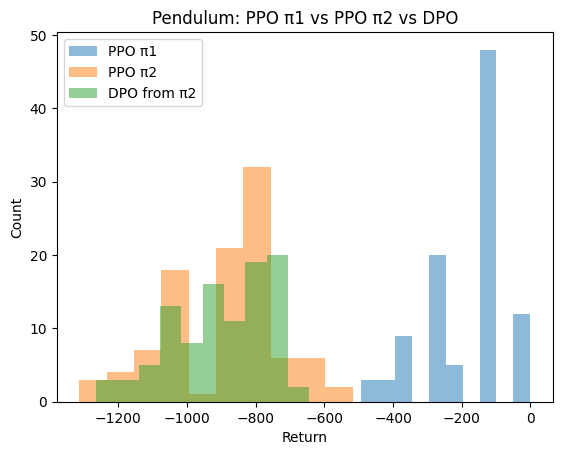

In [47]:
plt.hist(ppo_rewards1, alpha=0.5, label="PPO π1")
plt.hist(ppo_rewards2, alpha=0.5, label="PPO π2")
plt.hist(dpo_rewards, alpha=0.5, label="DPO from π2")
plt.legend()
plt.title("Pendulum: PPO π1 vs PPO π2 vs DPO")
plt.xlabel("Return")
plt.ylabel("Count")
plt.show()

In [28]:
def rollout_sb3_policy_with_seed(model, env_name="Pendulum-v1", seed=None, max_steps=200, deterministic=True):
    env = gym.make(env_name)

    obs, _ = env.reset(seed=seed)
    traj = []
    total_reward = 0.0

    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=deterministic)

        next_obs, reward, terminated, truncated, _ = env.step(action)

        traj.append((obs.copy(), action.copy(), reward))
        total_reward += reward

        obs = next_obs

        if terminated or truncated:
            break

    env.close()
    return traj, total_reward

In [29]:
def generate_same_start_preference_dataset(env_name, pi1_model, pi2_model, K=2000, seed_start=123):
    dataset = []

    for k in tqdm(range(K), desc="Generating same-start preference pairs"):
        seed = seed_start + k

        tau1, ret1 = rollout_sb3_policy_with_seed(
            pi1_model,
            env_name=env_name,
            seed=seed,
            deterministic=True
        )

        tau2, ret2 = rollout_sb3_policy_with_seed(
            pi2_model,
            env_name=env_name,
            seed=seed,
            deterministic=True
        )

        # Since π1 is much better, this will almost always choose τ1.
        # This is equivalent to exp(R1)/(exp(R1)+exp(R2)), but stable.
        diff = ret1 - ret2

        if diff > 50:
            p_tau1_preferred = 1.0
        elif diff < -50:
            p_tau1_preferred = 0.0
        else:
            p_tau1_preferred = 1.0 / (1.0 + np.exp(-diff))

        if np.random.rand() < p_tau1_preferred:
            pref, rej = tau1, tau2
            pref_ret, rej_ret = ret1, ret2
        else:
            pref, rej = tau2, tau1
            pref_ret, rej_ret = ret2, ret1

        dataset.append((pref, rej, pref_ret, rej_ret))

    return dataset

In [58]:
ppo_prefs = generate_same_start_preference_dataset(
    "Pendulum-v1",
    ppo_pi1,
    ppo_pi2,
    K=2000
)

Generating same-start preference pairs: 100%|██████████████████| 2000/2000 [06:39<00:00,  5.00it/s]


In [59]:
pref_returns = []
rej_returns = []
correct = 0

for pref, rej, pref_ret, rej_ret in ppo_prefs:
    pref_returns.append(pref_ret)
    rej_returns.append(rej_ret)

    if pref_ret >= rej_ret:
        correct += 1

print("Preferred trajectory has higher return fraction:", correct / len(ppo_prefs))
print("Mean preferred return:", np.mean(pref_returns))
print("Mean rejected return:", np.mean(rej_returns))

Preferred trajectory has higher return fraction: 1.0
Mean preferred return: -185.77752097826044
Mean rejected return: -923.0700605050919


In [60]:
env = gym.make("Pendulum-v1")

dpo_model = PPO.load("pendulum_ppo_pi2_final_half_minus939", env=env)
ref_model = PPO.load("pendulum_ppo_pi2_final_half_minus939", env=env)

trained_dpo_model, dpo_losses = train_sb3_dpo_stable(
    policy_model=dpo_model,
    ref_model=ref_model,
    prefs=ppo_prefs,
    epochs=1,
    batch_size=32,
    lr=5e-7,
    beta=0.005,
)

trained_dpo_model.save("pendulum_dpo_same_start_beta0005")

env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Stable DPO epoch 1/1: 100%|████████████████████████████████████████| 63/63 [00:06<00:00,  9.20it/s]

Epoch 1/1 | DPO loss: 0.6931


In [61]:
trained_dpo_model = PPO.load("pendulum_dpo_same_start_beta0005")

dpo_mean, dpo_std, dpo_rewards = evaluate_sb3_policy(
    trained_dpo_model,
    episodes=100
)

print("PPO π1:", ppo_mean1, ppo_std1)
print("PPO π2:", ppo_mean2, ppo_std2)
print("DPO:", dpo_mean, dpo_std)

PPO π1: -184.53224980412398 119.81637716992601
PPO π2: -886.4204705855301 165.91874525341592
DPO: -939.0902746627719 171.8229882553638


New one


In [10]:
def sb3_log_prob_actions(model, obs_batch, action_batch):
    obs_t = torch.tensor(
        obs_batch,
        dtype=torch.float32,
        device=model.policy.device
    )

    action_t = torch.tensor(
        action_batch,
        dtype=torch.float32,
        device=model.policy.device
    )

    dist = model.policy.get_distribution(obs_t)
    log_probs = dist.log_prob(action_t)

    return log_probs

In [31]:
def sb3_action_dpo_loss(policy_model, ref_model, batch, beta=0.2):
    obs = np.array([x[0] for x in batch], dtype=np.float32)
    a_plus = np.array([x[1] for x in batch], dtype=np.float32)
    a_minus = np.array([x[2] for x in batch], dtype=np.float32)

    logp_plus = sb3_log_prob_actions(policy_model, obs, a_plus)
    logp_minus = sb3_log_prob_actions(policy_model, obs, a_minus)

    with torch.no_grad():
        ref_logp_plus = sb3_log_prob_actions(ref_model, obs, a_plus)
        ref_logp_minus = sb3_log_prob_actions(ref_model, obs, a_minus)

    logits = beta * (
        (logp_plus - ref_logp_plus)
        -
        (logp_minus - ref_logp_minus)
    )

    loss = -F.logsigmoid(logits).mean()

    return loss

In [11]:
def train_sb3_action_dpo(
    policy_model,
    ref_model,
    dpo_data,
    epochs=5,
    batch_size=256,
    lr=1e-5,
    beta=0.2,
):
    policy_model.policy.train()
    ref_model.policy.eval()

    # freeze reference
    for p in ref_model.policy.parameters():
        p.requires_grad = False

    # train policy part, not value part
    for p in policy_model.policy.parameters():
        p.requires_grad = True

    if hasattr(policy_model.policy.mlp_extractor, "value_net"):
        for p in policy_model.policy.mlp_extractor.value_net.parameters():
            p.requires_grad = False

    for p in policy_model.policy.value_net.parameters():
        p.requires_grad = False

    # keep std fixed; we want to move the mean action
    if hasattr(policy_model.policy, "log_std"):
        policy_model.policy.log_std.requires_grad = False

    trainable_params = [
        p for p in policy_model.policy.parameters()
        if p.requires_grad
    ]

    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    losses = []

    for epoch in range(epochs):
        random.shuffle(dpo_data)

        total_loss = 0.0
        num_batches = 0

        for start in tqdm(
            range(0, len(dpo_data), batch_size),
            desc=f"Action-DPO epoch {epoch+1}/{epochs}"
        ):
            batch = dpo_data[start:start + batch_size]

            loss = sb3_action_dpo_loss(
                policy_model,
                ref_model,
                batch,
                beta=beta
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} | DPO loss = {avg_loss:.4f}")

    return policy_model, losses

In [76]:
action_dpo_results = []

betas = [1.0, 1.2, 1.5, 2.0, 3.0]

for beta in betas:
    print("\n==============================")
    print("Action-level DPO beta:", beta)
    print("==============================")

    env = gym.make("Pendulum-v1")

    dpo_model = PPO.load("pendulum_ppo_pi1_expert_minus180", env=env)
    ref_model = PPO.load("pendulum_ppo_pi1_expert_minus180", env=env)

    trained_model, losses = train_sb3_action_dpo(
        policy_model=dpo_model,
        ref_model=ref_model,
        dpo_data=dpo_action_prefs,
        epochs=5,
        batch_size=256,
        lr=1e-5,
        beta=beta,
    )

    mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
        trained_model,
        episodes=100
    )

    model_name = f"pendulum_action_dpo_beta_{beta}"
    trained_model.save(model_name)

    action_dpo_results.append({
        "beta": beta,
        "mean": mean_dpo,
        "std": std_dpo,
        "loss_last": losses[-1],
        "model": model_name,
        "rewards": rewards_dpo,
    })

    print("DPO mean:", mean_dpo)
    print("DPO std:", std_dpo)
    print("last loss:", losses[-1])

    env.close()

action_dpo_df = pd.DataFrame([
    {
        "beta": r["beta"],
        "mean": r["mean"],
        "std": r["std"],
        "loss_last": r["loss_last"],
        "model": r["model"],
    }
    for r in action_dpo_results
])

action_dpo_df


Action-level DPO beta: 0.05
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|█████████████████████████████████████| 235/235 [00:00<00:00, 241.69it/s]


Epoch 1/5 | DPO loss = 0.6843


Action-DPO epoch 2/5: 100%|█████████████████████████████████████| 235/235 [00:00<00:00, 244.80it/s]


Epoch 2/5 | DPO loss = 0.6686


...

Action-DPO epoch 4/5: 100%|█████████████████████████████████████| 235/235 [00:00<00:00, 248.86it/s]


Epoch 4/5 | DPO loss = 0.3980


Action-DPO epoch 5/5: 100%|█████████████████████████████████████| 235/235 [00:00<00:00, 248.01it/s]


Epoch 5/5 | DPO loss = 0.3740
DPO mean: -575.5117204026517
DPO std: 466.63162830096354
last loss: 0.37397381599913254


,beta,mean,std,loss_last,model
0,0.05,-1436.378756,232.618969,0.633120,pendulum_action_dpo_beta_0.05
1,0.10,-1341.376708,360.722185,0.594396,pendulum_action_dpo_beta_0.1
2,0.20,-1189.472138,462.162794,0.540593,pendulum_action_dpo_beta_0.2
3,0.40,-942.737276,531.090594,0.467508,pendulum_action_dpo_beta_0.4
4,0.60,-740.632765,535.255066,0.421029,pendulum_action_dpo_beta_0.6
5,0.90,-575.511720,466.631628,0.373974,pendulum_action_dpo_beta_0.9


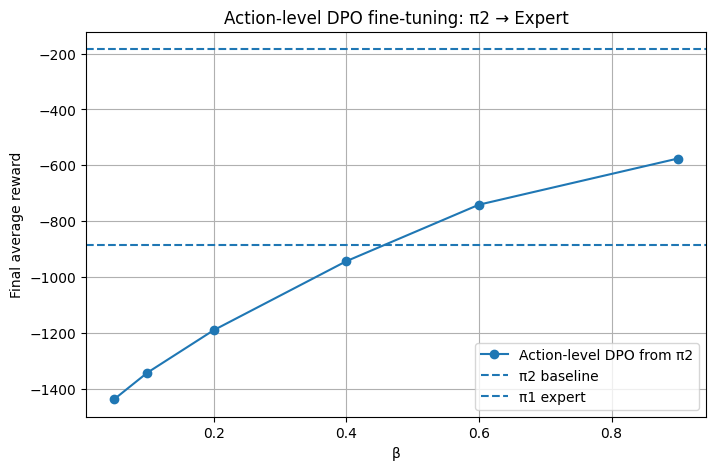

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    action_dpo_df["beta"],
    action_dpo_df["mean"],
    marker="o",
    label="Action-level DPO from π2"
)

plt.axhline(ppo_mean2, linestyle="--", label="π2 baseline")
plt.axhline(ppo_mean1, linestyle="--", label="π1 expert")

plt.xlabel("β")
plt.ylabel("Final average reward")
plt.title("Action-level DPO fine-tuning: π2 → Expert")
plt.legend()
plt.grid(True)
plt.show()

In [102]:
action_dpo_summary_df = (
    action_dpo_seed_df
    .groupby("beta")
    .agg(
        mean_avg=("mean", "mean"),
        mean_std=("mean", "std"),
        loss_last_avg=("loss_last", "mean"),
    )
    .reset_index()
)

action_dpo_summary_df

,beta,mean_avg,mean_std,loss_last_avg
0,0.1,-1370.452301,5.750243,0.594399
1,0.5,-854.087617,19.983595,0.442426
2,0.8,-627.461469,34.255245,0.387379
3,1.0,-431.586907,57.263789,0.361398
4,1.2,-449.871308,23.326926,0.340739
5,1.5,-284.071445,12.091509,0.316820
6,2.0,-231.075274,12.947794,0.286125
7,3.0,-193.685192,6.996582,0.244917
8,3.5,-180.024739,3.269226,0.229921
9,4.0,-185.901924,5.958741,0.217286


In [104]:
best_row = action_dpo_seed_df.loc[action_dpo_seed_df["mean"].idxmax()]

best_model_name = best_row["model"]
best_beta = best_row["beta"]
best_seed = best_row["seed"]
best_mean = best_row["mean"]

print("Best DPO model:", best_model_name)
print("Seed:", best_seed)
print("Beta:", best_beta)
print("Mean reward:", best_mean)

Best DPO model: pendulum_action_dpo_seed0_beta4p5
Seed: 0
Beta: 4.5
Mean reward: -166.2955605660547


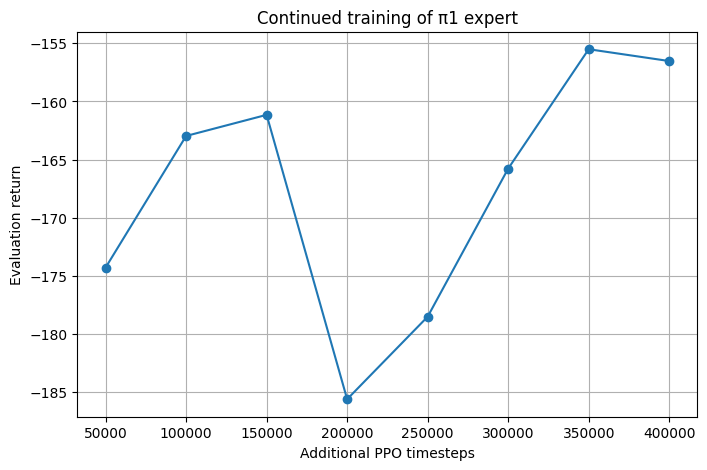

   chunk  additional_steps        mean         std  \
0      1             50000 -174.291903  104.496697   
1      2            100000 -162.967519  110.260536   
2      3            150000 -161.150441  107.559839   
3      4            200000 -185.614716  105.854760   
4      5            250000 -178.514841   98.299573   
5      6            300000 -165.775340  106.777966   
6      7            350000 -155.505455   98.947404   
7      8            400000 -156.522564   96.198139   

                                 path  
0  pendulum_pi1_more_chunk1_mean_-174  
1  pendulum_pi1_more_chunk2_mean_-162  
2  pendulum_pi1_more_chunk3_mean_-161  
3  pendulum_pi1_more_chunk4_mean_-185  
4  pendulum_pi1_more_chunk5_mean_-178  
5  pendulum_pi1_more_chunk6_mean_-165  
6  pendulum_pi1_more_chunk7_mean_-155  
7  pendulum_pi1_more_chunk8_mean_-156  
Best π1 so far: pendulum_pi1_more_chunk7_mean_-155 -155.5054550808297


In [18]:
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from stable_baselines3 import PPO
import numpy as np

# start from your current expert
BASE_PI1_PATH = "pendulum_ppo_pi1_expert_minus180"

env = gym.make("Pendulum-v1")
pi1_more = PPO.load(BASE_PI1_PATH, env=env)

records = []

best_mean = -1e9
best_path = None

CHUNK_STEPS = 50_000
NUM_CHUNKS = 8   # total additional = 400k steps

for chunk in range(1, NUM_CHUNKS + 1):
    pi1_more.learn(
        total_timesteps=CHUNK_STEPS,
        reset_num_timesteps=False
    )

    mean_reward, std_reward, rewards = evaluate_sb3_policy(
        pi1_more,
        episodes=300
    )

    path = f"pendulum_pi1_more_chunk{chunk}_mean_{int(mean_reward)}"
    pi1_more.save(path)

    records.append({
        "chunk": chunk,
        "additional_steps": chunk * CHUNK_STEPS,
        "mean": mean_reward,
        "std": std_reward,
        "path": path,
    })

    if mean_reward > best_mean:
        best_mean = mean_reward
        best_path = path

    clear_output(wait=True)

    df_pi1_more = pd.DataFrame(records)

    plt.figure(figsize=(8, 5))
    plt.plot(df_pi1_more["additional_steps"], df_pi1_more["mean"], marker="o")
    plt.xlabel("Additional PPO timesteps")
    plt.ylabel("Evaluation return")
    plt.title("Continued training of π1 expert")
    plt.grid(True)
    plt.show()

    print(df_pi1_more)
    print("Best π1 so far:", best_path, best_mean)

env.close()

pi1_more_records = pd.DataFrame(records)

In [19]:
best_pi1_model = PPO.load(best_path)

best_pi1_mean, best_pi1_std, best_pi1_rewards = evaluate_sb3_policy(
    best_pi1_model,
    episodes=500
)

print("Best improved π1:", best_pi1_mean, best_pi1_std)
print("Best path:", best_path)

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Best improved π1: -166.85045801725659 116.49771369913188
Best path: pendulum_pi1_more_chunk7_mean_-155


In [20]:
best_pi1_model.save("pendulum_ppo_pi1_final_stronger_minus155")

PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"

Let's do this

In [27]:
PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_ppo_pi2_final_half_minus939"

ppo_pi1 = PPO.load(PI1_PATH)
ppo_pi2 = PPO.load(PI2_PATH)

ppo_mean1, ppo_std1, ppo_rewards1 = evaluate_sb3_policy(
    ppo_pi1,
    episodes=300
)

ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(
    ppo_pi2,
    episodes=300
)

print("New stronger π1:", ppo_mean1, ppo_std1)
print("π2 baseline:", ppo_mean2, ppo_std2)

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


New stronger π1: -156.173959993268 99.87419995986278
π2 baseline: -920.460549108277 175.72613389896264


In [28]:
dpo_action_prefs = collect_action_preference_dataset(
    ppo_pi1,
    ppo_pi2,
    episodes=300
)

print("Number of action-level DPO samples:", len(dpo_action_prefs))

Number of action-level DPO samples: 60000


In [12]:
import random
import numpy as np
import torch

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Optional, for more reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [42]:
SEEDS = [0, 1, 2]
BETAS = [0.1, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 3.5, 4.0, 4.5]

all_action_dpo_results = []

for seed in SEEDS:
    print("\n====================================")
    print("SEED:", seed)
    print("====================================")

    set_all_seeds(seed)

    for beta in BETAS:
        print("\n==============================")
        print(f"Seed={seed} | Action-level DPO beta={beta}")
        print("==============================")

        env = gym.make("Pendulum-v1")
        # DPO starts from π2; stronger π1 is used only in the preference dataset
        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs,
            epochs=5,
            batch_size=256,
            lr=1e-5,
            beta=beta,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=100
        )

        beta_name = str(beta).replace(".", "p")
        model_name = f"pendulum_action_dpo_stronger_pi1_seed{seed}_beta{beta_name}"
        trained_model.save(model_name)

        all_action_dpo_results.append({
            "seed": seed,
            "beta": beta,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()



SEED: 0

Seed=0 | Action-level DPO beta=0.1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 239.18it/s]


Epoch 1/5 | DPO loss = 0.6860


Action-DPO epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 247.62it/s]


Epoch 2/5 | DPO loss = 0.6725


...

Epoch 3/5 | DPO loss = 0.4403


Action-DPO epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 250.74it/s]


Epoch 4/5 | DPO loss = 0.4238


Action-DPO epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 251.48it/s]


Epoch 5/5 | DPO loss = 0.4105
DPO mean: -1069.1580180870847
DPO std: 59.840342752032946
last loss: 0.41048939760695113


In [13]:
def evaluate_policy_on_fixed_seeds(model, env_name="Pendulum-v1", seeds=range(5000, 5100)):
    env = gym.make(env_name)
    rewards = []

    for seed in seeds:
        obs, _ = env.reset(seed=seed)
        done = False
        total_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    env.close()
    return np.array(rewards)

In [49]:
eval_seeds = range(5000, 5100)

pi1_rewards = evaluate_policy_on_fixed_seeds(pi1_model, seeds=eval_seeds)
pi2_rewards = evaluate_policy_on_fixed_seeds(pi2_model, seeds=eval_seeds)
dpo_rewards = evaluate_policy_on_fixed_seeds(dpo_model, seeds=eval_seeds)

print("π1:", pi1_rewards.mean(), pi1_rewards.std())
print("π2:", pi2_rewards.mean(), pi2_rewards.std())
print("DPO:", dpo_rewards.mean(), dpo_rewards.std())

π1: -163.0724693914118 102.03193303828911
π2: -909.7176249288714 178.74880979603506
DPO: -1069.8416282314556 46.79071605830181


In [50]:
tmp_env = gym.make("Pendulum-v1")
tmp_pi2 = PPO.load(PI2_PATH, env=tmp_env)

tmp_mean, tmp_std, _ = evaluate_sb3_policy(tmp_pi2, episodes=100)

print("Fresh π2 from PI2_PATH:", tmp_mean, tmp_std)

tmp_env.close()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Fresh π2 from PI2_PATH: -925.2396833406934 158.7150739453648


In [51]:
BETAS_EXTRA = [5.0, 7.0, 10.0, 15.0, 20.0]
SEEDS = [0, 1, 2]

extra_results = []

for seed in SEEDS:
    print("\n====================================")
    print("SEED:", seed)
    print("====================================")

    for beta in BETAS_EXTRA:
        print("\n==============================")
        print(f"Seed={seed} | Action-level DPO beta={beta}")
        print("==============================")

        set_all_seeds(seed)

        env = gym.make("Pendulum-v1")

        # Correct: DPO starts from π2, reference is frozen π2
        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs.copy(),
            epochs=5,
            batch_size=256,
            lr=1e-5,
            beta=beta,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=100
        )

        beta_name = str(beta).replace(".", "p")
        model_name = f"pendulum_action_dpo_from_pi2_stronger_pi1_seed{seed}_beta{beta_name}"
        trained_model.save(model_name)

        extra_results.append({
            "seed": seed,
            "beta": beta,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()

extra_seed_df = pd.DataFrame(extra_results)
extra_seed_df


SEED: 0

Seed=0 | Action-level DPO beta=5.0
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 248.12it/s]


Epoch 1/5 | DPO loss = 0.5479


Action-DPO epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 242.90it/s]


Epoch 2/5 | DPO loss = 0.4616


...

Action-DPO epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 254.35it/s]


Epoch 4/5 | DPO loss = 0.3167


Action-DPO epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 253.31it/s]


Epoch 5/5 | DPO loss = 0.2925
DPO mean: -931.8447656998676
DPO std: 115.53568587480663
last loss: 0.29249931022207787


,seed,beta,mean,std,loss_last,model,rewards
0,0,5.0,-1050.327296,57.151791,0.404045,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-946.7633566959482, -1084.970393411431, -1086..."
1,0,7.0,-1000.708277,62.597496,0.380011,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-936.3462035499749, -940.2827087888578, -922...."
2,0,10.0,-959.516108,80.946790,0.352517,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-949.6490790407719, -901.6340235681577, -1049..."
3,0,15.0,-936.750779,94.467243,0.318234,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-910.1778642438651, -924.9353488492815, -1045..."
4,0,20.0,-933.325096,110.774003,0.292499,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-1022.2162680751919, -892.3754873888782, -786..."
5,1,5.0,-1038.053327,66.699918,0.404045,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-1135.1302761732684, -1038.7159401130132, -10..."
6,1,7.0,-1015.676862,84.813733,0.380011,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-1060.2367842423232, -986.5499770360068, -105..."
7,1,10.0,-962.559990,92.621633,0.352517,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-966.7164917414475, -939.8602272892576, -770...."
8,1,15.0,-942.972379,106.178145,0.318234,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-827.7315542095694, -865.5422031775447, -894...."
9,1,20.0,-913.895206,97.235826,0.292499,pendulum_action_dpo_from_pi2_stronger_pi1_seed...,"[-913.4686435562943, -1206.4898292509095, -901..."


In [53]:
env = gym.make("Pendulum-v1")

pi2_more = PPO.load(PI2_PATH, env=env)

records = []

CHUNK_STEPS = 50_000
NUM_CHUNKS = 8

for chunk in range(1, NUM_CHUNKS + 1):
    pi2_more.learn(
        total_timesteps=CHUNK_STEPS,
        reset_num_timesteps=False
    )

    mean_reward, std_reward, _ = evaluate_sb3_policy(
        pi2_more,
        episodes=300
    )

    path = f"pendulum_pi2_more_chunk{chunk}_mean_{int(mean_reward)}"
    pi2_more.save(path)

    records.append({
        "chunk": chunk,
        "additional_steps": chunk * CHUNK_STEPS,
        "mean": mean_reward,
        "std": std_reward,
        "path": path,
    })

    print(records[-1])

env.close()

pi2_more_df = pd.DataFrame(records)
pi2_more_df

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -981     |
| time/              |          |
|    fps             | 695      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 122880   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -978         |
| time/                   |              |
|    fps                  | 438          |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 124928       |
| train/                  |              |
|    approx_kl            | 0.0046692835 |
|    clip_fraction        | 0.0526       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.11        |
|    explained_variance   | 2.92e-06     |
|    learning_r

,chunk,additional_steps,mean,std,path
0,1,50000,-828.062150,91.156075,pendulum_pi2_more_chunk1_mean_-828
1,2,100000,-205.673618,139.311319,pendulum_pi2_more_chunk2_mean_-205
2,3,150000,-198.543834,128.540865,pendulum_pi2_more_chunk3_mean_-198
3,4,200000,-254.103161,255.019325,pendulum_pi2_more_chunk4_mean_-254
4,5,250000,-210.441571,201.767421,pendulum_pi2_more_chunk5_mean_-210
5,6,300000,-210.522002,202.081196,pendulum_pi2_more_chunk6_mean_-210
6,7,350000,-173.587796,112.131887,pendulum_pi2_more_chunk7_mean_-173
7,8,400000,-158.012537,97.241023,pendulum_pi2_more_chunk8_mean_-158


In [54]:
env = gym.make("Pendulum-v1")

pi2_mid = PPO.load("pendulum_pi2_more_chunk1_mean_-828", env=env)

records_mid = []

CHUNK_STEPS = 10_000
NUM_CHUNKS = 5   # from 50k to 100k total

for chunk in range(1, NUM_CHUNKS + 1):
    pi2_mid.learn(
        total_timesteps=CHUNK_STEPS,
        reset_num_timesteps=False
    )

    mean_reward, std_reward, _ = evaluate_sb3_policy(
        pi2_mid,
        episodes=300
    )

    path = f"pendulum_pi2_mid_after_{50_000 + chunk * CHUNK_STEPS}_mean_{int(mean_reward)}"
    pi2_mid.save(path)

    records_mid.append({
        "additional_from_chunk1": chunk * CHUNK_STEPS,
        "total_extra_steps": 50_000 + chunk * CHUNK_STEPS,
        "mean": mean_reward,
        "std": std_reward,
        "path": path,
    })

    print(records_mid[-1])

env.close()

pi2_mid_df = pd.DataFrame(records_mid)
pi2_mid_df

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -919     |
| time/              |          |
|    fps             | 1067     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 174080   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -907         |
| time/                   |              |
|    fps                  | 824          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 176128       |
| train/                  |              |
|    approx_kl            | 0.0057788338 |
|    clip_fraction        | 0.066        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.981       |
|    explained_variance   | 0.823        |
|    learning_r

,additional_from_chunk1,total_extra_steps,mean,std,path
0,10000,60000,-734.624326,107.635353,pendulum_pi2_mid_after_60000_mean_-734
1,20000,70000,-719.054055,106.953110,pendulum_pi2_mid_after_70000_mean_-719
2,30000,80000,-391.603821,170.262776,pendulum_pi2_mid_after_80000_mean_-391
3,40000,90000,-366.553932,329.579521,pendulum_pi2_mid_after_90000_mean_-366
4,50000,100000,-239.894568,155.347374,pendulum_pi2_mid_after_100000_mean_-239


In [55]:
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

In [56]:
ppo_pi2 = PPO.load(PI2_PATH)

ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(
    ppo_pi2,
    episodes=300
)

print("Selected π2:", ppo_mean2, ppo_std2)

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Selected π2: -384.8195449055463 178.7363543522757


In [57]:
SEEDS = [0, 1, 2]
BETAS = [0.1, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 4.0, 5.0]

all_action_dpo_results = []

for seed in SEEDS:
    print("\n====================================")
    print("SEED:", seed)
    print("====================================")

    for beta in BETAS:
        print("\n==============================")
        print(f"Seed={seed} | Action-level DPO beta={beta}")
        print("==============================")

        set_all_seeds(seed)

        env = gym.make("Pendulum-v1")

        # Correct: DPO starts from π2, reference is frozen π2
        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs.copy(),
            epochs=5,
            batch_size=256,
            lr=1e-5,
            beta=beta,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=100
        )

        beta_name = str(beta).replace(".", "p")
        model_name = f"pendulum_action_dpo_from_pi2_mid_seed{seed}_beta{beta_name}"
        trained_model.save(model_name)

        all_action_dpo_results.append({
            "seed": seed,
            "beta": beta,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()

action_dpo_seed_df = pd.DataFrame(all_action_dpo_results)
action_dpo_seed_df


SEED: 0

Seed=0 | Action-level DPO beta=0.1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 251.97it/s]


Epoch 1/5 | DPO loss = 0.6785


Action-DPO epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 252.36it/s]


Epoch 2/5 | DPO loss = 0.6533


...

Action-DPO epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 251.05it/s]


Epoch 4/5 | DPO loss = 0.2505


Action-DPO epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 247.36it/s]


Epoch 5/5 | DPO loss = 0.2253
DPO mean: -449.509593417689
DPO std: 287.35577684499333
last loss: 0.22529452994782873


,seed,beta,mean,std,loss_last,model,rewards
0,0,0.1,-1439.863651,71.711867,0.604348,pendulum_action_dpo_from_pi2_mid_seed0_beta0p1,"[-1518.3090955198847, -1428.6262063774213, -13..."
1,0,0.5,-1178.772421,59.165019,0.479279,pendulum_action_dpo_from_pi2_mid_seed0_beta0p5,"[-1227.52425704063, -1245.2928901738169, -1238..."
2,0,0.8,-1083.408391,73.144930,0.432946,pendulum_action_dpo_from_pi2_mid_seed0_beta0p8,"[-1097.0776623567406, -1090.7900675526926, -10..."
3,0,1.0,-1034.269054,77.938804,0.409747,pendulum_action_dpo_from_pi2_mid_seed0_beta1p0,"[-1075.273594579739, -1039.7713879754938, -947..."
4,0,1.2,-988.883084,85.584558,0.389662,pendulum_action_dpo_from_pi2_mid_seed0_beta1p2,"[-933.4655373797776, -839.1776784022163, -1018..."
5,0,1.5,-892.272966,120.512508,0.363615,pendulum_action_dpo_from_pi2_mid_seed0_beta1p5,"[-939.5392832206517, -966.24945963683, -913.64..."
6,0,2.0,-738.593085,190.014875,0.328728,pendulum_action_dpo_from_pi2_mid_seed0_beta2p0,"[-892.0026267379352, -893.2654282811975, -917...."
7,0,3.0,-590.858373,305.250973,0.280218,pendulum_action_dpo_from_pi2_mid_seed0_beta3p0,"[-883.3450318411514, -1.4340362308350052, -775..."
8,0,4.0,-508.754367,287.690764,0.248106,pendulum_action_dpo_from_pi2_mid_seed0_beta4p0,"[-257.89105646473985, -518.2537320607748, -137..."
9,0,5.0,-508.376207,267.086751,0.225295,pendulum_action_dpo_from_pi2_mid_seed0_beta5p0,"[-680.6115951911335, -270.2249052953456, -442...."


In [59]:
DIAG_SEED = 0
DIAG_BETAS = [5.0, 7.0, 10.0, 15.0]

diagnostic_results = []

for beta in DIAG_BETAS:
    print("\n==============================")
    print(f"Diagnostic DPO | beta={beta}")
    print("==============================")

    set_all_seeds(DIAG_SEED)

    env = gym.make("Pendulum-v1")

    # Correct: DPO starts from selected π2
    dpo_model = PPO.load(PI2_PATH, env=env)
    ref_model = PPO.load(PI2_PATH, env=env)

    for epoch in range(1, 6):
        dpo_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs.copy(),
            epochs=1,              # one epoch at a time
            batch_size=256,
            lr=1e-5,
            beta=beta,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            dpo_model,
            episodes=100
        )

        model_name = f"diag_dpo_from_pi2_beta{str(beta).replace('.', 'p')}_epoch{epoch}"
        dpo_model.save(model_name)

        diagnostic_results.append({
            "beta": beta,
            "epoch": epoch,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss": losses[-1],
            "model": model_name,
        })

        print(
            f"beta={beta} | epoch={epoch} | "
            f"mean={mean_dpo:.2f} | std={std_dpo:.2f} | loss={losses[-1]:.4f}"
        )

    env.close()

diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



Diagnostic DPO | beta=5.0
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 244.32it/s]


Epoch 1/1 | DPO loss = 0.4774
beta=5.0 | epoch=1 | mean=-427.07 | std=208.30 | loss=0.4774


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 249.36it/s]


...

Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 249.77it/s]


Epoch 1/1 | DPO loss = 0.1584
beta=15.0 | epoch=4 | mean=-400.65 | std=191.92 | loss=0.1584


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 246.25it/s]


Epoch 1/1 | DPO loss = 0.1424
beta=15.0 | epoch=5 | mean=-341.66 | std=199.82 | loss=0.1424


,beta,epoch,mean,std,loss,model
0,5.0,1,-427.073539,208.300138,0.477450,diag_dpo_from_pi2_beta5p0_epoch1
1,5.0,2,-444.894991,250.912782,0.348722,diag_dpo_from_pi2_beta5p0_epoch2
2,5.0,3,-492.391945,238.678487,0.289918,diag_dpo_from_pi2_beta5p0_epoch3
3,5.0,4,-523.960792,231.876066,0.251938,diag_dpo_from_pi2_beta5p0_epoch4
4,5.0,5,-553.571847,248.645659,0.226009,diag_dpo_from_pi2_beta5p0_epoch5
5,7.0,1,-441.367790,198.144781,0.448328,diag_dpo_from_pi2_beta7p0_epoch1
6,7.0,2,-449.938179,242.888713,0.310661,diag_dpo_from_pi2_beta7p0_epoch2
7,7.0,3,-390.644150,228.796188,0.251947,diag_dpo_from_pi2_beta7p0_epoch3
8,7.0,4,-461.524567,237.999042,0.217703,diag_dpo_from_pi2_beta7p0_epoch4
9,7.0,5,-460.901258,242.556194,0.195241,diag_dpo_from_pi2_beta7p0_epoch5


In [60]:
DIAG_SEED = 0
DIAG_BETAS = [5.0, 7.0, 10.0, 15.0]

diagnostic_results = []

for beta in DIAG_BETAS:
    set_all_seeds(DIAG_SEED)

    env = gym.make("Pendulum-v1")

    dpo_model = PPO.load(PI2_PATH, env=env)
    ref_model = PPO.load(PI2_PATH, env=env)

    # epoch 0 = before DPO training
    mean0, std0, _ = evaluate_sb3_policy(dpo_model, episodes=100)

    diagnostic_results.append({
        "beta": beta,
        "epoch": 0,
        "mean": mean0,
        "std": std0,
        "loss": None,
        "model": "initial_pi2"
    })

    for epoch in range(1, 6):
        dpo_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs.copy(),
            epochs=1,
            batch_size=256,
            lr=1e-5,
            beta=beta,
        )

        mean_dpo, std_dpo, _ = evaluate_sb3_policy(dpo_model, episodes=100)

        diagnostic_results.append({
            "beta": beta,
            "epoch": epoch,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss": losses[-1],
            "model": f"beta{beta}_epoch{epoch}"
        })

    env.close()

diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00

Epoch 1/1 | DPO loss = 0.4774


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 249.53it/s]


Epoch 1/1 | DPO loss = 0.3487


...

Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 259.14it/s]


Epoch 1/1 | DPO loss = 0.1584


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 259.61it/s]


Epoch 1/1 | DPO loss = 0.1424


,beta,epoch,mean,std,loss,model
0,5.0,0,-372.128688,145.953124,NaN,initial_pi2
1,5.0,1,-509.269218,193.989634,0.477450,beta5.0_epoch1
2,5.0,2,-443.327990,220.240854,0.348722,beta5.0_epoch2
3,5.0,3,-516.346988,225.677835,0.289918,beta5.0_epoch3
4,5.0,4,-493.274916,253.309947,0.251938,beta5.0_epoch4
5,5.0,5,-493.404596,272.212757,0.226009,beta5.0_epoch5
6,7.0,0,-381.599567,133.148509,NaN,initial_pi2
7,7.0,1,-476.567354,212.599190,0.448328,beta7.0_epoch1
8,7.0,2,-473.560442,193.094255,0.310661,beta7.0_epoch2
9,7.0,3,-422.011138,239.359569,0.251947,beta7.0_epoch3


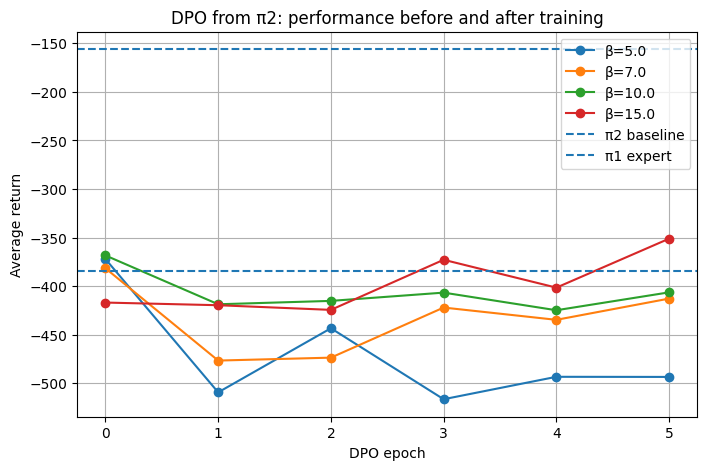

In [61]:
plt.figure(figsize=(8, 5))

for beta in DIAG_BETAS:
    df_beta = diagnostic_df[diagnostic_df["beta"] == beta]
    plt.plot(df_beta["epoch"], df_beta["mean"], marker="o", label=f"β={beta}")

plt.axhline(ppo_mean2, linestyle="--", label="π2 baseline")
plt.axhline(ppo_mean1, linestyle="--", label="π1 expert")

plt.xlabel("DPO epoch")
plt.ylabel("Average return")
plt.title("DPO from π2: performance before and after training")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
TEST_SETTINGS = [
    {"beta": 10.0, "lr": 1e-5},
    {"beta": 10.0, "lr": 3e-5},
    {"beta": 10.0, "lr": 5e-5},

    {"beta": 15.0, "lr": 1e-5},
    {"beta": 15.0, "lr": 3e-5},
    {"beta": 15.0, "lr": 5e-5},

    {"beta": 20.0, "lr": 1e-5},
    {"beta": 20.0, "lr": 3e-5},
    {"beta": 20.0, "lr": 5e-5},

    {"beta": 25.0, "lr": 1e-5},
    {"beta": 25.0, "lr": 3e-5},
]

DIAG_SEED = 0
MAX_EPOCHS = 5

hyper_diag_results = []

for setting in TEST_SETTINGS:
    beta = setting["beta"]
    lr = setting["lr"]

    print("\n====================================")
    print(f"Diagnostic | beta={beta} | lr={lr}")
    print("====================================")

    set_all_seeds(DIAG_SEED)

    env = gym.make("Pendulum-v1")

    dpo_model = PPO.load(PI2_PATH, env=env)
    ref_model = PPO.load(PI2_PATH, env=env)

    # epoch 0 = before DPO training
    mean0, std0, _ = evaluate_sb3_policy(
        dpo_model,
        episodes=100
    )

    hyper_diag_results.append({
        "beta": beta,
        "lr": lr,
        "epoch": 0,
        "mean": mean0,
        "std": std0,
        "loss": None,
        "model": "initial_pi2"
    })

    print(f"epoch=0 | mean={mean0:.2f} | std={std0:.2f}")

    for epoch in range(1, MAX_EPOCHS + 1):
        dpo_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs.copy(),
            epochs=1,
            batch_size=256,
            lr=lr,
            beta=beta,
        )

        mean_dpo, std_dpo, _ = evaluate_sb3_policy(
            dpo_model,
            episodes=100
        )

        model_name = (
            f"diag_dpo_beta{str(beta).replace('.', 'p')}"
            f"_lr{str(lr).replace('.', 'p').replace('-', 'm')}"
            f"_epoch{epoch}"
        )

        dpo_model.save(model_name)

        hyper_diag_results.append({
            "beta": beta,
            "lr": lr,
            "epoch": epoch,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss": losses[-1],
            "model": model_name,
        })

        print(
            f"epoch={epoch} | mean={mean_dpo:.2f} | "
            f"std={std_dpo:.2f} | loss={losses[-1]:.4f}"
        )

    env.close()

hyper_diag_df = pd.DataFrame(hyper_diag_results)
hyper_diag_df


Diagnostic | beta=10.0 | lr=1e-05
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


epoch=0 | mean=-390.43 | std=188.77


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 252.88it/s]


Epoch 1/1 | DPO loss = 0.4152
epoch=1 | mean=-413.75 | std=194.88 | loss=0.4152


...

Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 249.79it/s]


Epoch 1/1 | DPO loss = 0.0839
epoch=4 | mean=-284.59 | std=165.07 | loss=0.0839


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 246.82it/s]


Epoch 1/1 | DPO loss = 0.0761
epoch=5 | mean=-230.67 | std=146.44 | loss=0.0761


,beta,lr,epoch,mean,std,loss,model
0,10.0,0.00001,0,-390.429454,188.774691,NaN,initial_pi2
1,10.0,0.00001,1,-413.750324,194.883280,0.415234,diag_dpo_beta10p0_lr1em05_epoch1
2,10.0,0.00001,2,-400.571412,221.731000,0.270591,diag_dpo_beta10p0_lr1em05_epoch2
3,10.0,0.00001,3,-400.663018,221.027310,0.216303,diag_dpo_beta10p0_lr1em05_epoch3
4,10.0,0.00001,4,-401.767032,233.603935,0.187125,diag_dpo_beta10p0_lr1em05_epoch4
...,...,...,...,...,...,...,...
61,25.0,0.00003,1,-349.155518,168.288875,0.225552,diag_dpo_beta25p0_lr3em05_epoch1
62,25.0,0.00003,2,-307.591215,174.355318,0.119147,diag_dpo_beta25p0_lr3em05_epoch2
63,25.0,0.00003,3,-303.308208,180.740855,0.096018,diag_dpo_beta25p0_lr3em05_epoch3
64,25.0,0.00003,4,-284.585286,165.074506,0.083928,diag_dpo_beta25p0_lr3em05_epoch4


Best diagnostic result:
beta                                 15.0
lr                                0.00005
epoch                                   5
mean                          -223.493566
std                            131.324133
loss                             0.076097
model    diag_dpo_beta15p0_lr5em05_epoch5
Name: 35, dtype: object
π2 baseline: -384.8195449055463
π1 expert: -156.173959993268


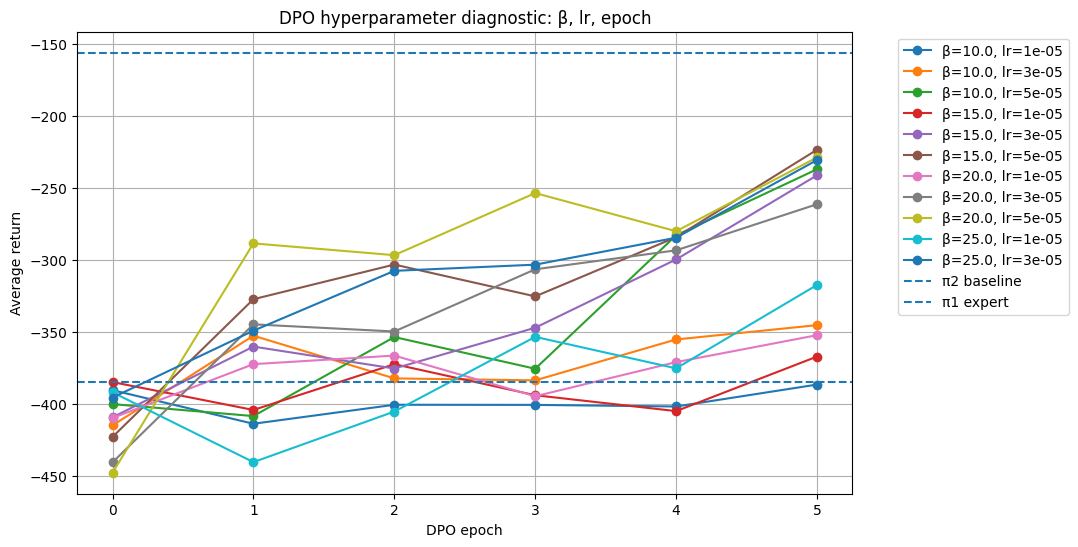

In [63]:
best_hyper_row = hyper_diag_df.loc[hyper_diag_df["mean"].idxmax()]

print("Best diagnostic result:")
print(best_hyper_row)

print("π2 baseline:", ppo_mean2)
print("π1 expert:", ppo_mean1)
plt.figure(figsize=(10, 6))

for (beta, lr), df_group in hyper_diag_df.groupby(["beta", "lr"]):
    plt.plot(
        df_group["epoch"],
        df_group["mean"],
        marker="o",
        label=f"β={beta}, lr={lr}"
    )

plt.axhline(ppo_mean2, linestyle="--", label="π2 baseline")
plt.axhline(ppo_mean1, linestyle="--", label="π1 expert")

plt.xlabel("DPO epoch")
plt.ylabel("Average return")
plt.title("DPO hyperparameter diagnostic: β, lr, epoch")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [64]:
DIAG_SEED = 0

TEST_BETAS = [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0]
TEST_LRS = [1e-5, 3e-5, 5e-5]

MAX_EPOCHS = 5

small_beta_diag_results = []

for lr in TEST_LRS:
    for beta in TEST_BETAS:
        print("\n====================================")
        print(f"Diagnostic | beta={beta} | lr={lr}")
        print("====================================")

        set_all_seeds(DIAG_SEED)

        env = gym.make("Pendulum-v1")

        # DPO starts from selected π2
        dpo_model = PPO.load(PI2_PATH, env=env)

        # frozen reference = selected π2
        ref_model = PPO.load(PI2_PATH, env=env)

        # epoch 0 = before DPO
        mean0, std0, _ = evaluate_sb3_policy(
            dpo_model,
            episodes=100
        )

        small_beta_diag_results.append({
            "beta": beta,
            "lr": lr,
            "epoch": 0,
            "mean": mean0,
            "std": std0,
            "loss": None,
            "model": "initial_pi2"
        })

        print(f"epoch=0 | mean={mean0:.2f} | std={std0:.2f}")

        for epoch in range(1, MAX_EPOCHS + 1):
            dpo_model, losses = train_sb3_action_dpo(
                policy_model=dpo_model,
                ref_model=ref_model,
                dpo_data=dpo_action_prefs.copy(),
                epochs=1,
                batch_size=256,
                lr=lr,
                beta=beta,
            )

            mean_dpo, std_dpo, _ = evaluate_sb3_policy(
                dpo_model,
                episodes=100
            )

            model_name = (
                f"diag_small_beta_dpo_beta{str(beta).replace('.', 'p')}"
                f"_lr{str(lr).replace('.', 'p').replace('-', 'm')}"
                f"_epoch{epoch}"
            )

            dpo_model.save(model_name)

            small_beta_diag_results.append({
                "beta": beta,
                "lr": lr,
                "epoch": epoch,
                "mean": mean_dpo,
                "std": std_dpo,
                "loss": losses[-1],
                "model": model_name,
            })

            print(
                f"epoch={epoch} | mean={mean_dpo:.2f} | "
                f"std={std_dpo:.2f} | loss={losses[-1]:.4f}"
            )

        env.close()

small_beta_diag_df = pd.DataFrame(small_beta_diag_results)
small_beta_diag_df


Diagnostic | beta=0.5 | lr=1e-05
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


epoch=0 | mean=-400.53 | std=187.72


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 251.19it/s]


Epoch 1/1 | DPO loss = 0.6319
epoch=1 | mean=-861.27 | std=198.25 | loss=0.6319


...

Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 253.82it/s]


Epoch 1/1 | DPO loss = 0.0840
epoch=4 | mean=-291.47 | std=163.26 | loss=0.0840


Action-DPO epoch 1/1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 255.46it/s]


Epoch 1/1 | DPO loss = 0.0761
epoch=5 | mean=-208.65 | std=144.61 | loss=0.0761


,beta,lr,epoch,mean,std,loss,model
0,0.5,0.00001,0,-400.528046,187.721042,NaN,initial_pi2
1,0.5,0.00001,1,-861.272924,198.254623,0.631853,diag_small_beta_dpo_beta0p5_lr1em05_epoch1
2,0.5,0.00001,2,-1080.875297,91.083773,0.560307,diag_small_beta_dpo_beta0p5_lr1em05_epoch2
3,0.5,0.00001,3,-1147.703250,63.261014,0.523796,diag_small_beta_dpo_beta0p5_lr1em05_epoch3
4,0.5,0.00001,4,-1166.866983,64.576230,0.495450,diag_small_beta_dpo_beta0p5_lr1em05_epoch4
...,...,...,...,...,...,...,...
139,15.0,0.00005,1,-311.308912,169.195641,0.225499,diag_small_beta_dpo_beta15p0_lr5em05_epoch1
140,15.0,0.00005,2,-340.430358,192.357716,0.118709,diag_small_beta_dpo_beta15p0_lr5em05_epoch2
141,15.0,0.00005,3,-313.021604,180.843843,0.095800,diag_small_beta_dpo_beta15p0_lr5em05_epoch3
142,15.0,0.00005,4,-291.467262,163.260568,0.083954,diag_small_beta_dpo_beta15p0_lr5em05_epoch4


In [65]:
best_small_beta_row = small_beta_diag_df.loc[
    small_beta_diag_df["mean"].idxmax()
]

print("Best diagnostic result:")
print(best_small_beta_row)

print("π2 baseline:", ppo_mean2)
print("π1 expert:", ppo_mean1)

Best diagnostic result:
beta                                            15.0
lr                                           0.00005
epoch                                              5
mean                                     -208.653109
std                                        144.61243
loss                                        0.076097
model    diag_small_beta_dpo_beta15p0_lr5em05_epoch5
Name: 143, dtype: object
π2 baseline: -384.8195449055463
π1 expert: -156.173959993268


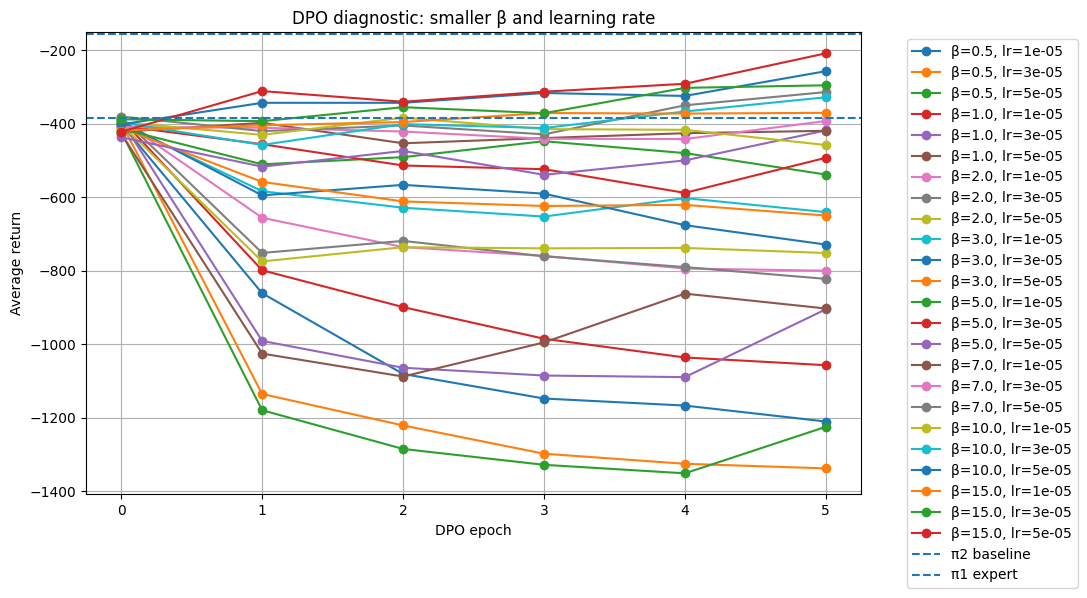

In [66]:
plt.figure(figsize=(10, 6))

for (beta, lr), df_group in small_beta_diag_df.groupby(["beta", "lr"]):
    plt.plot(
        df_group["epoch"],
        df_group["mean"],
        marker="o",
        label=f"β={beta}, lr={lr}"
    )

plt.axhline(ppo_mean2, linestyle="--", label="π2 baseline")
plt.axhline(ppo_mean1, linestyle="--", label="π1 expert")

plt.xlabel("DPO epoch")
plt.ylabel("Average return")
plt.title("DPO diagnostic: smaller β and learning rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [67]:
small_beta_diag_df.sort_values("mean", ascending=False).head(15)

,beta,lr,epoch,mean,std,loss,model
143,15.0,0.00005,5,-208.653109,144.612430,0.076097,diag_small_beta_dpo_beta15p0_lr5em05_epoch5
137,10.0,0.00005,5,-257.229738,153.765306,0.087892,diag_small_beta_dpo_beta10p0_lr5em05_epoch5
142,15.0,0.00005,4,-291.467262,163.260568,0.083954,diag_small_beta_dpo_beta15p0_lr5em05_epoch4
95,15.0,0.00003,5,-295.598138,169.766267,0.091620,diag_small_beta_dpo_beta15p0_lr3em05_epoch5
94,15.0,0.00003,4,-302.600756,186.311440,0.101635,diag_small_beta_dpo_beta15p0_lr3em05_epoch4
139,15.0,0.00005,1,-311.308912,169.195641,0.225499,diag_small_beta_dpo_beta15p0_lr5em05_epoch1
141,15.0,0.00005,3,-313.021604,180.843843,0.095800,diag_small_beta_dpo_beta15p0_lr5em05_epoch3
131,7.0,0.00005,5,-314.073781,207.470519,0.100668,diag_small_beta_dpo_beta7p0_lr5em05_epoch5
135,10.0,0.00005,3,-316.556730,222.646869,0.112241,diag_small_beta_dpo_beta10p0_lr5em05_epoch3
136,10.0,0.00005,4,-324.554469,211.967643,0.097626,diag_small_beta_dpo_beta10p0_lr5em05_epoch4


In [68]:
SEEDS = [0, 1, 2]

BETAS = [5.0, 7.0, 10.0, 12.0, 15.0, 18.0, 20.0]
LR = 5e-5
EPOCHS = 5

beta_sweep_results = []

for seed in SEEDS:
    print("\n====================================")
    print("SEED:", seed)
    print("====================================")

    for beta in BETAS:
        print("\n==============================")
        print(f"Seed={seed} | beta={beta} | lr={LR} | epochs={EPOCHS}")
        print("==============================")

        set_all_seeds(seed)

        env = gym.make("Pendulum-v1")

        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_action_prefs.copy(),
            epochs=EPOCHS,
            batch_size=256,
            lr=LR,
            beta=beta,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=300
        )

        beta_name = str(beta).replace(".", "p")
        model_name = f"dpo_from_pi2_beta{beta_name}_lr5e5_seed{seed}"
        trained_model.save(model_name)

        beta_sweep_results.append({
            "seed": seed,
            "beta": beta,
            "lr": LR,
            "epochs": EPOCHS,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()

beta_sweep_df = pd.DataFrame(beta_sweep_results)
beta_sweep_df

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



SEED: 0

Seed=0 | beta=5.0 | lr=5e-05 | epochs=5
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 253.34it/s]


Epoch 1/5 | DPO loss = 0.3238


Action-DPO epoch 2/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 255.12it/s]


...

Action-DPO epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 253.30it/s]


Epoch 4/5 | DPO loss = 0.0779


Action-DPO epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 252.82it/s]


Epoch 5/5 | DPO loss = 0.0717
DPO mean: -247.19197341511094
DPO std: 148.00624667455418
last loss: 0.07170210691525582


,seed,beta,lr,epochs,mean,std,loss_last,model,rewards
0,0,5.0,0.00005,5,-440.094262,320.740527,0.123962,dpo_from_pi2_beta5p0_lr5e5_seed0,"[-770.0041172931304, -738.5707584537653, -386...."
1,0,7.0,0.00005,5,-360.820179,244.125612,0.107602,dpo_from_pi2_beta7p0_lr5e5_seed0,"[-645.7372445779612, -245.62223998063405, -134..."
2,0,10.0,0.00005,5,-290.415311,182.073320,0.093079,dpo_from_pi2_beta10p0_lr5e5_seed0,"[-481.49615393108337, -251.729500555028, -130...."
3,0,12.0,0.00005,5,-277.215676,161.301260,0.086644,dpo_from_pi2_beta12p0_lr5e5_seed0,"[-262.6923206103087, -525.4270134859249, -129...."
4,0,15.0,0.00005,5,-256.495799,159.439353,0.079584,dpo_from_pi2_beta15p0_lr5e5_seed0,"[-2.1923806876595204, -134.439604043426, -1.09..."
5,0,18.0,0.00005,5,-263.846387,144.727535,0.074439,dpo_from_pi2_beta18p0_lr5e5_seed0,"[-395.6161611843948, -398.7484244814306, -393...."
6,0,20.0,0.00005,5,-259.652881,153.934276,0.071702,dpo_from_pi2_beta20p0_lr5e5_seed0,"[-382.4212853271947, -258.14077247013705, -295..."
7,1,5.0,0.00005,5,-443.116761,317.525001,0.123962,dpo_from_pi2_beta5p0_lr5e5_seed1,"[-1.3542575069579939, -0.9077549870203707, -3...."
8,1,7.0,0.00005,5,-357.856615,240.753812,0.107602,dpo_from_pi2_beta7p0_lr5e5_seed1,"[-1.9688417538349594, -529.9764797437549, -0.8..."
9,1,10.0,0.00005,5,-283.211542,188.533854,0.093079,dpo_from_pi2_beta10p0_lr5e5_seed1,"[-1.1597940783474119, -250.43397282213115, -37..."


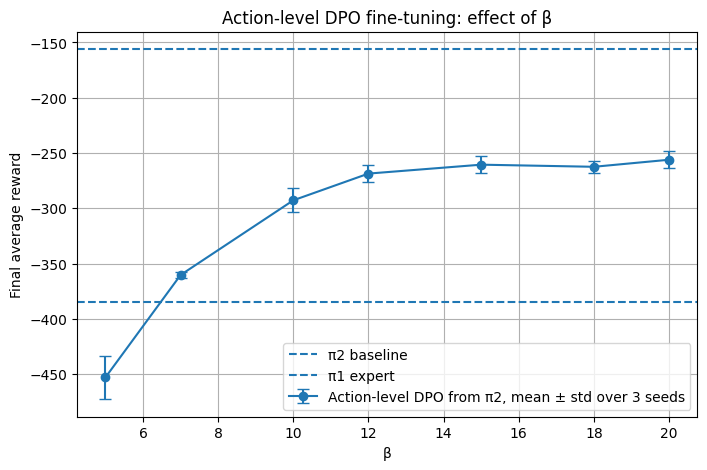

In [69]:
beta_summary_df = (
    beta_sweep_df
    .groupby("beta")
    .agg(
        mean_avg=("mean", "mean"),
        mean_std=("mean", "std"),
        loss_last_avg=("loss_last", "mean"),
    )
    .reset_index()
)

beta_summary_df
plt.figure(figsize=(8, 5))

plt.errorbar(
    beta_summary_df["beta"],
    beta_summary_df["mean_avg"],
    yerr=beta_summary_df["mean_std"],
    marker="o",
    capsize=4,
    label="Action-level DPO from π2, mean ± std over 3 seeds"
)

plt.axhline(ppo_mean2, linestyle="--", label="π2 baseline")
plt.axhline(ppo_mean1, linestyle="--", label="π1 expert")

plt.xlabel("β")
plt.ylabel("Final average reward")
plt.title("Action-level DPO fine-tuning: effect of β")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

ppo_pi1 = PPO.load(PI1_PATH)
ppo_pi2 = PPO.load(PI2_PATH)

ppo_mean1, ppo_std1, ppo_rewards1 = evaluate_sb3_policy(
    ppo_pi1,
    episodes=300
)

ppo_mean2, ppo_std2, ppo_rewards2 = evaluate_sb3_policy(
    ppo_pi2,
    episodes=300
)

print("π1 expert:", ppo_mean1, ppo_std1)
print("π2 selected:", ppo_mean2, ppo_std2)

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


π1 expert: -182.90135251616059 167.18315713459188
π2 selected: -397.4309078277206 174.84744018490022


In [24]:
dpo_action_prefs = collect_action_preference_dataset(
    ppo_pi1,
    ppo_pi2,
    episodes=300
)

print("Number of DPO action preferences:", len(dpo_action_prefs))

Number of DPO action preferences: 60000


In [27]:
def check_action_pref_dataset(ppo_pi1, ppo_pi2, dpo_action_prefs, n=1000):
    idxs = np.random.choice(
        len(dpo_action_prefs),
        size=min(n, len(dpo_action_prefs)),
        replace=False
    )

    pi1_errors = []
    pi2_errors = []

    for idx in idxs:
        obs, a_plus_data, a_minus_data = dpo_action_prefs[idx]

        a_plus_now, _ = ppo_pi1.predict(obs, deterministic=True)
        a_minus_now, _ = ppo_pi2.predict(obs, deterministic=True)

        pi1_errors.append(np.abs(a_plus_now - a_plus_data).mean())
        pi2_errors.append(np.abs(a_minus_now - a_minus_data).mean())

    print("Mean |stored a+ - current π1 action|:", np.mean(pi1_errors))
    print("Mean |stored a- - current π2 action|:", np.mean(pi2_errors))

In [28]:
check_action_pref_dataset(ppo_pi1, ppo_pi2, dpo_action_prefs)

Mean |stored a+ - current π1 action|: 0.0
Mean |stored a- - current π2 action|: 0.0


In [30]:
import pandas as pd
epoch_diag_df = pd.DataFrame(epoch_diag_results)
epoch_diag_df

,beta,lr,epoch,mean,std,loss,model
0,12.0,0.00005,0,-409.917568,175.978196,NaN,initial_pi2
1,12.0,0.00005,1,-603.845254,201.539598,0.353375,epoch_diag_dpo_beta12p0_lr5e5_epoch1
2,12.0,0.00005,2,-636.343623,319.582653,0.270097,epoch_diag_dpo_beta12p0_lr5e5_epoch2
3,12.0,0.00005,3,-714.910529,338.989294,0.245412,epoch_diag_dpo_beta12p0_lr5e5_epoch3
4,12.0,0.00005,4,-684.278441,383.423428,0.232075,epoch_diag_dpo_beta12p0_lr5e5_epoch4
5,12.0,0.00005,5,-698.595116,391.840644,0.222530,epoch_diag_dpo_beta12p0_lr5e5_epoch5
6,12.0,0.00005,6,-774.240525,372.351378,0.215416,epoch_diag_dpo_beta12p0_lr5e5_epoch6
7,12.0,0.00005,7,-730.547003,405.748459,0.209293,epoch_diag_dpo_beta12p0_lr5e5_epoch7
8,12.0,0.00005,8,-691.877633,446.053769,0.204085,epoch_diag_dpo_beta12p0_lr5e5_epoch8
9,12.0,0.00005,9,-683.637602,457.932823,0.199141,epoch_diag_dpo_beta12p0_lr5e5_epoch9


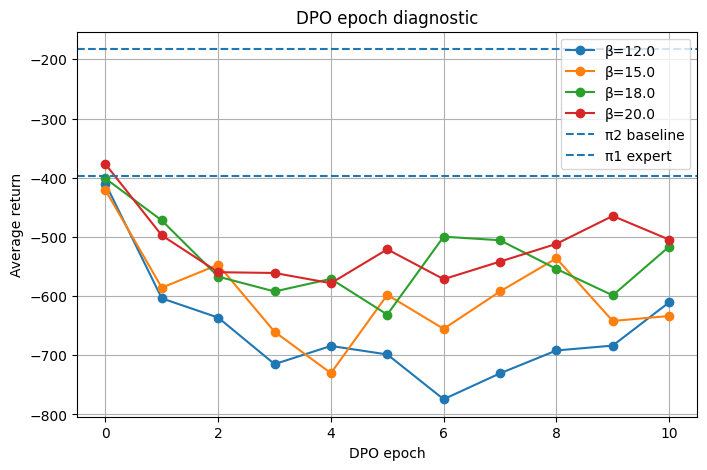

In [31]:
plt.figure(figsize=(8, 5))

for beta in EPOCH_TEST_BETAS:
    df_beta = epoch_diag_df[epoch_diag_df["beta"] == beta]

    plt.plot(
        df_beta["epoch"],
        df_beta["mean"],
        marker="o",
        label=f"β={beta}"
    )

plt.axhline(ppo_mean2, linestyle="--", label="π2 baseline")
plt.axhline(ppo_mean1, linestyle="--", label="π1 expert")

plt.xlabel("DPO epoch")
plt.ylabel("Average return")
plt.title("DPO epoch diagnostic")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
SEEDS = [0, 1, 2]

DATASET_EPISODES = [50, 100, 300, 1000]

BEST_BETA = 15.0
BEST_LR = 5e-5
BEST_EPOCHS = 5

dataset_size_results = []

for dataset_episodes in DATASET_EPISODES:
    print("\n====================================")
    print("DATASET EPISODES:", dataset_episodes)
    print("====================================")

    for seed in SEEDS:
        print("\n------------------------------")
        print(f"Dataset episodes={dataset_episodes} | seed={seed}")
        print("------------------------------")

        set_all_seeds(seed)

        # regenerate dataset for this size
        dpo_prefs_size = collect_action_preference_dataset(
            ppo_pi1,
            ppo_pi2,
            episodes=dataset_episodes
        )

        print("Number of action preferences:", len(dpo_prefs_size))

        env = gym.make("Pendulum-v1")

        # DPO starts from π2, reference is frozen π2
        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_prefs_size.copy(),
            epochs=BEST_EPOCHS,
            batch_size=256,
            lr=BEST_LR,
            beta=BEST_BETA,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=300
        )

        model_name = (
            f"dpo_dataset{dataset_episodes}"
            f"_beta{str(BEST_BETA).replace('.', 'p')}"
            f"_lr5e5_seed{seed}"
        )
        trained_model.save(model_name)

        dataset_size_results.append({
            "dataset_episodes": dataset_episodes,
            "num_action_preferences": len(dpo_prefs_size),
            "seed": seed,
            "beta": BEST_BETA,
            "lr": BEST_LR,
            "epochs": BEST_EPOCHS,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()

dataset_size_df = pd.DataFrame(dataset_size_results)
dataset_size_df


DATASET EPISODES: 50

------------------------------
Dataset episodes=50 | seed=0
------------------------------


/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Number of action preferences: 10000
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 87.28it/s]


Epoch 1/5 | DPO loss = 0.4677


...

Action-DPO epoch 4/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:03<00:00, 248.18it/s]


Epoch 4/5 | DPO loss = 0.1886


Action-DPO epoch 5/5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [00:03<00:00, 248.99it/s]


Epoch 5/5 | DPO loss = 0.1790
DPO mean: -597.6998333011344
DPO std: 454.4119717456052
last loss: 0.17898989120102904


,dataset_episodes,num_action_preferences,seed,beta,lr,epochs,mean,std,loss_last,model,rewards
0,50,10000,0,15.0,0.00005,5,-528.540738,251.011438,0.297553,dpo_dataset50_beta15p0_lr5e5_seed0,"[-644.6404370701673, -252.35379950507846, -129..."
1,50,10000,1,15.0,0.00005,5,-519.698260,265.758971,0.297553,dpo_dataset50_beta15p0_lr5e5_seed1,"[-127.75281517650653, -782.6841727282423, -644..."
2,50,10000,2,15.0,0.00005,5,-547.230635,230.926586,0.297553,dpo_dataset50_beta15p0_lr5e5_seed2,"[-126.08685252773047, -884.6680677536046, -579..."
3,100,20000,0,15.0,0.00005,5,-561.427922,296.547459,0.257777,dpo_dataset100_beta15p0_lr5e5_seed0,"[-759.7326986834383, -428.0428405354259, -524...."
4,100,20000,1,15.0,0.00005,5,-579.977590,282.727643,0.257777,dpo_dataset100_beta15p0_lr5e5_seed1,"[-1.5688622577521314, -745.0239545642015, -515..."
5,100,20000,2,15.0,0.00005,5,-563.993279,282.312753,0.257777,dpo_dataset100_beta15p0_lr5e5_seed2,"[-133.99317615201994, -767.2259239596024, -750..."
6,300,60000,0,15.0,0.00005,5,-593.756207,353.191531,0.221690,dpo_dataset300_beta15p0_lr5e5_seed0,"[-913.6530568987649, -892.7501457075297, -905...."
7,300,60000,1,15.0,0.00005,5,-634.325710,342.729731,0.221690,dpo_dataset300_beta15p0_lr5e5_seed1,"[-742.7264819423643, -786.5848622315273, -131...."
8,300,60000,2,15.0,0.00005,5,-612.348099,355.397134,0.221690,dpo_dataset300_beta15p0_lr5e5_seed2,"[-1.7762912113465943, -901.3853524319371, -887..."
9,1000,200000,0,15.0,0.00005,5,-620.782919,457.137952,0.178990,dpo_dataset1000_beta15p0_lr5e5_seed0,"[-123.85971742532338, -1.201240885037586, -106..."


In [35]:
PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

ppo_pi1 = PPO.load(PI1_PATH)
ppo_pi2 = PPO.load(PI2_PATH)

ppo_mean1, ppo_std1, _ = evaluate_sb3_policy(ppo_pi1, episodes=300)
ppo_mean2, ppo_std2, _ = evaluate_sb3_policy(ppo_pi2, episodes=300)

print("π1 expert:", ppo_mean1, ppo_std1)
print("π2 baseline:", ppo_mean2, ppo_std2)

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


π1 expert: -168.6365077898385 131.5220654855418
π2 baseline: -406.6254052180751 189.78694080257043


In [14]:
def collect_action_preference_dataset_seeded(
    pi1_model,
    pi2_model,
    env_name="Pendulum-v1",
    episodes=300,
    seed_start=0,
):
    env = gym.make(env_name)
    data = []

    for ep in tqdm(range(episodes), desc=f"Collecting DPO data ({episodes} episodes)"):
        obs, _ = env.reset(seed=seed_start + ep)
        done = False

        while not done:
            a_plus, _ = pi1_model.predict(obs, deterministic=True)
            a_minus, _ = pi2_model.predict(obs, deterministic=True)

            data.append((obs.copy(), a_plus.copy(), a_minus.copy()))

            # sample states by following π2
            obs, reward, terminated, truncated, _ = env.step(a_minus)
            done = terminated or truncated

    env.close()
    return data

In [37]:
SEEDS = [0, 1, 2]

# Nested subset sizes in number of action-level preference samples
DATASET_SIZES = [10_000, 20_000, 60_000, 100_000]

BIG_POOL_EPISODES = 600  # around 120k samples

BEST_BETA = 20.0
BEST_LR = 5e-5
BEST_EPOCHS = 5

nested_dataset_results = []

for seed in SEEDS:
    print("\n====================================")
    print("SEED:", seed)
    print("====================================")

    set_all_seeds(seed)

    # Make one big pool for this seed
    big_pool = collect_action_preference_dataset_seeded(
        ppo_pi1,
        ppo_pi2,
        episodes=BIG_POOL_EPISODES,
        seed_start=500_000 + seed * 100_000,
    )

    print("Big pool size:", len(big_pool))

    # Shuffle once, then take nested subsets
    rng = random.Random(10_000 + seed)
    rng.shuffle(big_pool)

    for dataset_size in DATASET_SIZES:
        assert dataset_size <= len(big_pool), (
            f"dataset_size={dataset_size} is larger than pool size={len(big_pool)}"
        )

        dpo_data_subset = big_pool[:dataset_size]

        print("\n------------------------------")
        print(f"Seed={seed} | N={dataset_size} | beta={BEST_BETA}")
        print("------------------------------")

        set_all_seeds(seed)

        env = gym.make("Pendulum-v1")

        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_data_subset.copy(),
            epochs=BEST_EPOCHS,
            batch_size=256,
            lr=BEST_LR,
            beta=BEST_BETA,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=300
        )

        model_name = (
            f"dpo_nested_N{dataset_size}"
            f"_beta{str(BEST_BETA).replace('.', 'p')}"
            f"_lr5e5_seed{seed}"
        )
        trained_model.save(model_name)

        nested_dataset_results.append({
            "seed": seed,
            "dataset_size": dataset_size,
            "beta": BEST_BETA,
            "lr": BEST_LR,
            "epochs": BEST_EPOCHS,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()

nested_dataset_df = pd.DataFrame(nested_dataset_results)
nested_dataset_df


SEED: 0


Big pool size: 120000

------------------------------
Seed=0 | N=10000 | beta=20.0
------------------------------
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 256.45it/s]


Epoch 1/5 | DPO loss = 0.4381


Action-DPO epoch 2/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 261.56it/s]


...

Action-DPO epoch 4/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:01<00:00, 260.20it/s]


Epoch 4/5 | DPO loss = 0.2024


Action-DPO epoch 5/5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:01<00:00, 256.07it/s]


Epoch 5/5 | DPO loss = 0.1943
DPO mean: -531.2671001777751
DPO std: 357.7892568326062
last loss: 0.19433145259347412


,seed,dataset_size,beta,lr,epochs,mean,std,loss_last,model,rewards
0,0,10000,20.0,0.00005,5,-489.832752,239.727117,0.278245,dpo_nested_N10000_beta20p0_lr5e5_seed0,"[-259.61554160584126, -765.8467718115265, -775..."
1,0,20000,20.0,0.00005,5,-516.891913,263.109387,0.249766,dpo_nested_N20000_beta20p0_lr5e5_seed0,"[-253.38619593799527, -761.3903128842846, -766..."
2,0,60000,20.0,0.00005,5,-516.779585,334.473533,0.213902,dpo_nested_N60000_beta20p0_lr5e5_seed0,"[-882.9769278890875, -785.8575800865804, -909...."
3,0,100000,20.0,0.00005,5,-513.807824,343.996218,0.195849,dpo_nested_N100000_beta20p0_lr5e5_seed0,"[-258.5974733382553, -842.9929372694112, -804...."
4,1,10000,20.0,0.00005,5,-516.660339,234.873458,0.292416,dpo_nested_N10000_beta20p0_lr5e5_seed1,"[-2.9515625122620004, -399.39762939416255, -51..."
5,1,20000,20.0,0.00005,5,-503.972979,281.160524,0.251130,dpo_nested_N20000_beta20p0_lr5e5_seed1,"[-805.6833857223705, -402.8371145310107, -503...."
6,1,60000,20.0,0.00005,5,-521.007738,324.014638,0.215340,dpo_nested_N60000_beta20p0_lr5e5_seed1,"[-779.9885146111159, -124.59045603572243, -130..."
7,1,100000,20.0,0.00005,5,-549.762873,343.304369,0.196770,dpo_nested_N100000_beta20p0_lr5e5_seed1,"[-388.1801244485234, -275.51993582253033, -283..."
8,2,10000,20.0,0.00005,5,-497.451812,245.588340,0.280542,dpo_nested_N10000_beta20p0_lr5e5_seed2,"[-128.09575445821608, -262.7350652018723, -761..."
9,2,20000,20.0,0.00005,5,-540.793250,268.915457,0.246400,dpo_nested_N20000_beta20p0_lr5e5_seed2,"[-130.0896681015383, -260.3426088864634, -131...."


In [38]:
nested_dataset_summary_df = (
    nested_dataset_df
    .groupby("dataset_size")
    .agg(
        mean_avg=("mean", "mean"),
        mean_std=("mean", "std"),
        loss_last_avg=("loss_last", "mean"),
    )
    .reset_index()
)

nested_dataset_summary_df

,dataset_size,mean_avg,mean_std,loss_last_avg
0,10000,-501.314968,13.824719,0.283734
1,20000,-520.552714,18.681118,0.249099
2,60000,-521.873944,5.578133,0.213311
3,100000,-531.612599,17.980014,0.195650


In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


import torch
import torch.nn.functional as F

from stable_baselines3 import PPO
PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

ppo_pi1 = PPO.load(PI1_PATH)
ppo_pi2 = PPO.load(PI2_PATH)

ppo_mean1, ppo_std1, _ = evaluate_sb3_policy(ppo_pi1, episodes=300)
ppo_mean2, ppo_std2, _ = evaluate_sb3_policy(ppo_pi2, episodes=300)

print("π1 expert:", ppo_mean1, ppo_std1)
print("π2 baseline:", ppo_mean2, ppo_std2)

In [ ]:
def collect_action_preference_dataset_seeded(
    pi1_model,
    pi2_model,
    env_name="Pendulum-v1",
    episodes=300,
    seed_start=0,
):
    env = gym.make(env_name)
    data = []

    for ep in tqdm(range(episodes), desc=f"Collecting DPO data ({episodes} episodes)"):
        obs, _ = env.reset(seed=seed_start + ep)
        done = False

        while not done:
            a_plus, _ = pi1_model.predict(obs, deterministic=True)
            a_minus, _ = pi2_model.predict(obs, deterministic=True)

            data.append((obs.copy(), a_plus.copy(), a_minus.copy()))

            # sample states by following π2
            obs, reward, terminated, truncated, _ = env.step(a_minus)
            done = terminated or truncated

    env.close()
    return data

In [32]:
SEEDS = [0, 1, 2]

# Nested subset sizes in number of action-level preference samples
DATASET_SIZES = [10_000, 20_000, 60_000, 100_000]

BIG_POOL_EPISODES = 600  # around 120k samples

BEST_BETA = 20.0
BEST_LR = 5e-5
BEST_EPOCHS = 5

nested_dataset_results = []

for seed in SEEDS:
    print("\n====================================")
    print("SEED:", seed)
    print("====================================")

    set_all_seeds(seed)

    # Make one big pool for this seed
    big_pool = collect_action_preference_dataset_seeded(
        ppo_pi1,
        ppo_pi2,
        episodes=BIG_POOL_EPISODES,
        seed_start=500_000 + seed * 100_000,
    )

    print("Big pool size:", len(big_pool))

    # Shuffle once, then take nested subsets
    rng = random.Random(10_000 + seed)
    rng.shuffle(big_pool)

    for dataset_size in DATASET_SIZES:
        assert dataset_size <= len(big_pool), (
            f"dataset_size={dataset_size} is larger than pool size={len(big_pool)}"
        )

        dpo_data_subset = big_pool[:dataset_size]

        print("\n------------------------------")
        print(f"Seed={seed} | N={dataset_size} | beta={BEST_BETA}")
        print("------------------------------")

        set_all_seeds(seed)

        env = gym.make("Pendulum-v1")

        dpo_model = PPO.load(PI2_PATH, env=env)
        ref_model = PPO.load(PI2_PATH, env=env)

        trained_model, losses = train_sb3_action_dpo(
            policy_model=dpo_model,
            ref_model=ref_model,
            dpo_data=dpo_data_subset.copy(),
            epochs=BEST_EPOCHS,
            batch_size=256,
            lr=BEST_LR,
            beta=BEST_BETA,
        )

        mean_dpo, std_dpo, rewards_dpo = evaluate_sb3_policy(
            trained_model,
            episodes=300
        )

        model_name = (
            f"dpo_nested_N{dataset_size}"
            f"_beta{str(BEST_BETA).replace('.', 'p')}"
            f"_lr5e5_seed{seed}"
        )
        trained_model.save(model_name)

        nested_dataset_results.append({
            "seed": seed,
            "dataset_size": dataset_size,
            "beta": BEST_BETA,
            "lr": BEST_LR,
            "epochs": BEST_EPOCHS,
            "mean": mean_dpo,
            "std": std_dpo,
            "loss_last": losses[-1],
            "model": model_name,
            "rewards": rewards_dpo,
        })

        print("DPO mean:", mean_dpo)
        print("DPO std:", std_dpo)
        print("last loss:", losses[-1])

        env.close()

nested_dataset_df = pd.DataFrame(nested_dataset_results)
nested_dataset_df


SEED: 0


Big pool size: 120000

------------------------------
Seed=0 | N=10000 | beta=20.0
------------------------------
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Action-DPO epoch 1/5: 100%|████████████████████████████████████████| 40/40 [00:03<00:00, 11.55it/s]


Epoch 1/5 | DPO loss = 0.4381


Action-DPO epoch 2/5: 100%|███████████████████████████████████████| 40/40 [00:00<00:00, 236.26it/s]


...

Action-DPO epoch 4/5: 100%|█████████████████████████████████████| 391/391 [00:01<00:00, 236.21it/s]


Epoch 4/5 | DPO loss = 0.2024


Action-DPO epoch 5/5: 100%|█████████████████████████████████████| 391/391 [00:01<00:00, 237.20it/s]


Epoch 5/5 | DPO loss = 0.1943
DPO mean: -505.074824375948
DPO std: 351.4354224098325
last loss: 0.19433145259347412


,seed,dataset_size,beta,lr,epochs,mean,std,loss_last,model,rewards
0,0,10000,20.0,0.00005,5,-496.364145,247.197816,0.278245,dpo_nested_N10000_beta20p0_lr5e5_seed0,"[-576.2185457875445, -256.4012441574469, -918...."
1,0,20000,20.0,0.00005,5,-515.341995,273.687313,0.249766,dpo_nested_N20000_beta20p0_lr5e5_seed0,"[-694.8319053764307, -647.0283148410596, -763...."
2,0,60000,20.0,0.00005,5,-537.231986,318.942757,0.213902,dpo_nested_N60000_beta20p0_lr5e5_seed0,"[-797.1830318771523, -794.669637681769, -595.3..."
3,0,100000,20.0,0.00005,5,-523.158579,343.051623,0.195849,dpo_nested_N100000_beta20p0_lr5e5_seed0,"[-275.8200269494323, -931.2865503095701, -130...."
4,1,10000,20.0,0.00005,5,-485.315900,257.429907,0.292416,dpo_nested_N10000_beta20p0_lr5e5_seed1,"[-254.77117749359354, -640.936697218825, -670...."
5,1,20000,20.0,0.00005,5,-505.842289,294.209163,0.251130,dpo_nested_N20000_beta20p0_lr5e5_seed1,"[-641.4509667295749, -522.0670861695659, -766...."
6,1,60000,20.0,0.00005,5,-542.367532,328.862619,0.215340,dpo_nested_N60000_beta20p0_lr5e5_seed1,"[-910.1793074329086, -749.6284050042601, -775...."
7,1,100000,20.0,0.00005,5,-520.768267,372.834661,0.196770,dpo_nested_N100000_beta20p0_lr5e5_seed1,"[-849.7024159454168, -1.027333472792167, -256...."
8,2,10000,20.0,0.00005,5,-496.855009,243.891662,0.280542,dpo_nested_N10000_beta20p0_lr5e5_seed2,"[-943.0231363121519, -639.587463775413, -646.8..."
9,2,20000,20.0,0.00005,5,-534.168326,280.383600,0.246400,dpo_nested_N20000_beta20p0_lr5e5_seed2,"[-128.36736350216597, -959.0287417339892, -747..."


In [33]:
nested_dataset_summary_df = (
    nested_dataset_df
    .groupby("dataset_size")
    .agg(
        mean_avg=("mean", "mean"),
        mean_std=("mean", "std"),
        loss_last_avg=("loss_last", "mean"),
    )
    .reset_index()
)

nested_dataset_summary_df

,dataset_size,mean_avg,mean_std,loss_last_avg
0,10000,-492.845018,6.525025,0.283734
1,20000,-518.450870,14.416654,0.249099
2,60000,-522.649342,29.816168,0.213311
3,100000,-516.333890,9.823610,0.195650


In [36]:
import os
import pickle

DPO_PREFS_PATH = "dpo_action_prefs_pi1_stronger_pi2_mid_300eps.pkl"

PI1_PATH = "pendulum_ppo_pi1_final_stronger_minus155"
PI2_PATH = "pendulum_pi2_mid_after_80000_mean_-391"

ppo_pi1 = PPO.load(PI1_PATH)
ppo_pi2 = PPO.load(PI2_PATH)

ppo_mean1, ppo_std1, _ = evaluate_sb3_policy(ppo_pi1, episodes=300)
ppo_mean2, ppo_std2, _ = evaluate_sb3_policy(ppo_pi2, episodes=300)

print("π1 expert:", ppo_mean1, ppo_std1)
print("π2 baseline:", ppo_mean2, ppo_std2)

if os.path.exists(DPO_PREFS_PATH):
    print("Loading existing DPO preference dataset...")
    with open(DPO_PREFS_PATH, "rb") as f:
        dpo_action_prefs = pickle.load(f)
else:
    print("Preference dataset not found. Regenerating...")
    dpo_action_prefs = collect_action_preference_dataset(
        ppo_pi1,
        ppo_pi2,
        episodes=300
    )

    with open(DPO_PREFS_PATH, "wb") as f:
        pickle.dump(dpo_action_prefs, f)

print("Current dpo_action_prefs size:", len(dpo_action_prefs))

/home/mduric/miniconda3/envs/nanofm/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


π1 expert: -160.4470871161997 103.45706837444631
π2 baseline: -401.57915977787894 175.96809060597846
Preference dataset not found. Regenerating...


Current dpo_action_prefs size: 60000


In [37]:
import os
import glob
import pickle

glob.glob("*dpo*")

['epoch_diag_dpo_beta20p0_lr5e5_epoch10.zip',
 'pendulum_action_dpo_stronger_pi1_seed1_beta3p5.zip',
 'diag_small_beta_dpo_beta10p0_lr1em05_epoch5.zip',
 'diag_small_beta_dpo_beta1p0_lr5em05_epoch5.zip',
 'pendulum_dpo_sweep_4.zip',
 'pendulum_action_dpo_seed2_beta3p0.zip',
 'diag_small_beta_dpo_beta15p0_lr3em05_epoch5.zip',
 'diag_small_beta_dpo_beta7p0_lr1em05_epoch5.zip',
 'diag_small_beta_dpo_beta5p0_lr3em05_epoch5.zip',
 'pendulum_action_dpo_seed0_beta5p0.zip',
 'dpo_nested_N100000_beta20p0_lr5e5_seed0.zip',
 'diag_dpo_beta10p0_lr5em05_epoch4.zip',
 'pendulum_action_dpo_stronger_pi1_seed0_beta1p0.zip',
 'diag_dpo_beta25p0_lr1em05_epoch3.zip',
 'diag_dpo_beta15p0_lr5em05_epoch2.zip',
 'diag_dpo_from_pi2_beta5p0_epoch5.zip',
 'pendulum_action_dpo_stronger_pi1_seed2_beta0p8.zip',
 'dpo_from_pi2_beta10p0_lr5e5_seed0.zip',
 'epoch_diag_dpo_beta20p0_lr5e5_epoch3.zip',
 'pendulum_action_dpo_seed1_beta1p5.zip',
 'diag_dpo_beta20p0_lr5em05_epoch4.zip',
 'diag_small_beta_dpo_beta2p0_lr3em05